# 🔍 Anomaly Detection cho Multi-Table Database

Notebook này tự động phát hiện các giá trị bất thường (outliers, nulls, duplicates, format errors...) trong tất cả các bảng của database.

**Workflow:**
1. Kết nối database (DuckDB hoặc load CSV/Parquet)
2. Profiling tổng quát từng bảng
3. Phát hiện anomalies theo từng loại cột
4. Visualize kết quả
5. Xuất báo cáo HTML

In [1]:
# ============================================================
# 📚 IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from pathlib import Path
from datetime import datetime
import json, re, os
from IPython.display import display, HTML, Markdown

import sys
import os
sys.path.append(os.path.abspath('..'))
from src.connection import get_connection


In [2]:


# # Style
# plt.rcParams.update({
#     'figure.dpi': 120,
#     'figure.facecolor': '#0f1117',
#     'axes.facecolor': '#1a1d27',
#     'axes.edgecolor': '#2d3142',
#     'axes.labelcolor': '#c8ccd8',
#     'xtick.color': '#8b92a5',
#     'ytick.color': '#8b92a5',
#     'text.color': '#c8ccd8',
#     'grid.color': '#2d3142',
#     'grid.alpha': 0.5,
#     'font.family': 'monospace',
# })
# PALETTE = ['#4cc9f0', '#f72585', '#7209b7', '#3a0ca3', '#4361ee', '#4cc9f0', '#06d6a0', '#ffd166']

# print('✅ Imports OK')
# print(f'   pandas     {pd.__version__}')
# print(f'   duckdb     {duckdb.__version__}')
# print(f'   matplotlib {matplotlib.__version__}')

---
## ⚙️ CELL 1 – CẤU HÌNH (chỉnh sửa tại đây)

In [3]:
# # ============================================================
# # ⚙️  CẤU HÌNH – chỉ cần chỉnh phần này
# # ============================================================

# # --- Nguồn dữ liệu ---
# # Chọn một trong 3 mode: 'duckdb_file' | 'csv_folder' | 'demo'
# DATA_SOURCE = 'demo'          # ← đổi thành 'duckdb_file' hoặc 'csv_folder' khi dùng thật

# DB_PATH     = 'mydb.duckdb'   # dùng khi DATA_SOURCE = 'duckdb_file'
# CSV_FOLDER  = './data'        # dùng khi DATA_SOURCE = 'csv_folder' (load tất cả *.csv)

# --- Ngưỡng phát hiện anomaly ---
CFG = dict(
    # Null / missing
    null_warn_pct        = 5.0,   # cảnh báo nếu % null > 5%
    null_critical_pct    = 20.0,  # nghiêm trọng nếu % null > 20%

    # Outlier số học (IQR)
    iqr_multiplier       = 1.5,   # hệ số IQR
    zscore_threshold     = 3.0,   # |z| > ngưỡng này → outlier

    # Isolation Forest (multivariate)
    iso_contamination    = 0.05,  # ước tính ~5% bất thường
    iso_random_state     = 42,
    iso_min_cols         = 2,     # chỉ chạy khi có >=2 cột số

    # Cardinality
    low_card_nunique     = 1,     # cột chỉ có 1 giá trị duy nhất
    high_card_cat_pct    = 90,    # cột text có > 90% unique → có thể là ID

    # Sample size để vẽ chart (lấy random để nhanh)
    plot_sample          = 50_000,
    
    # Số bảng tối đa hiển thị outlier rows
    display_rows         = 10,
)

# OUTPUT_DIR = Path('./anomaly_report')
# OUTPUT_DIR.mkdir(exist_ok=True)

print('✅ Config loaded')

✅ Config loaded


---
## 📂 CELL 2 – Load dữ liệu vào DuckDB

In [4]:

# 1. Gọi hàm kết nối DuckDB
con = get_connection()

# 2. Xem danh sách các bảng hiện có
print("--- DANH SÁCH BẢNG TRONG DATABASE ---")
tables = con.execute("SHOW TABLES").df()
display(tables)
tables_name = tables["name"]
# display(tables["name"])

# 3. Trinh sát bảng Đơn hàng (Dựa vào lỗi cũ, có vẻ bảng chính tên là 'orders')
try:
    print("\n--- 5 DÒNG ĐẦU BẢNG ORDERS ---")
    df_orders = con.execute("SELECT * FROM orders LIMIT 5").df()
    display(df_orders)
except:
    print("Không tìm thấy bảng 'orders', hãy nhìn danh sách bảng ở trên xem tên thực tế là gì nhé!")

--- DANH SÁCH BẢNG TRONG DATABASE ---


,name
0,customers
1,geography
2,inventory
3,order_items
4,orders
5,payments
6,products
7,promotions
8,returns
9,reviews



--- 5 DÒNG ĐẦU BẢNG ORDERS ---


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


---
## 🔬 CELL 3 – Hàm phân tích anomaly

In [5]:
# ============================================================
# 🔬 Anomaly Detection Engine
# ============================================================

def classify_columns(df):
    """Phân loại cột: numeric / datetime / categorical / text"""
    num_cols  = df.select_dtypes(include='number').columns.tolist()
    dt_cols   = df.select_dtypes(include='datetime').columns.tolist()
    cat_cols  = df.select_dtypes(include=['object','category','bool']).columns.tolist()
    return num_cols, dt_cols, cat_cols


def analyze_nulls(df, cfg):
    """Phân tích missing values theo từng cột."""
    total = len(df)
    records = []
    for col in df.columns:
        n_null = int(df[col].isna().sum())
        pct    = round(n_null / total * 100, 2) if total else 0
        level  = ('OK' if pct == 0
                  else 'WARN' if pct < cfg['null_critical_pct']
                  else 'CRITICAL')
        records.append({'column': col, 'null_count': n_null, 'null_pct': pct, 'level': level})
    return pd.DataFrame(records)


def analyze_duplicates(df):
    """Phát hiện duplicate rows."""
    n_dup = int(df.duplicated().sum())
    return {'n_duplicates': n_dup, 'pct': round(n_dup / max(len(df),1) * 100, 2)}


def analyze_numeric_outliers(df, num_cols, cfg):
    """IQR + Z-score cho từng cột numeric."""
    results = {}
    for col in num_cols:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr    = q3 - q1
        lb, ub = q1 - cfg['iqr_multiplier']*iqr, q3 + cfg['iqr_multiplier']*iqr
        iqr_mask = (df[col] < lb) | (df[col] > ub)

        if s.std() > 0:
            z = np.abs(stats.zscore(s))
            zs_idx = s.index[z > cfg['zscore_threshold']]
            zs_mask = df.index.isin(zs_idx)
        else:
            zs_mask = pd.Series(False, index=df.index)

        combined = iqr_mask | zs_mask
        results[col] = {
            'mean': round(float(s.mean()), 4),
            'std':  round(float(s.std()),  4),
            'min':  round(float(s.min()),  4),
            'max':  round(float(s.max()),  4),
            'q1': round(float(q1), 4), 'q3': round(float(q3), 4),
            'iqr_lower': round(float(lb), 4), 'iqr_upper': round(float(ub), 4),
            'n_iqr_outliers':  int(iqr_mask.sum()),
            'n_zscore_outliers': int(zs_mask.sum()),
            'n_total_outliers': int(combined.sum()),
            'outlier_pct': round(combined.sum() / max(len(df),1) * 100, 2),
            'outlier_mask': combined,
        }
    return results


def analyze_isolation_forest(df, num_cols, cfg):
    """Multivariate anomaly detection bằng Isolation Forest."""
    if len(num_cols) < cfg['iso_min_cols']:
        return None, None
    sub = df[num_cols].dropna()
    if len(sub) < 10:
        return None, None
    scaler = StandardScaler()
    X = scaler.fit_transform(sub)
    clf = IsolationForest(
        contamination=cfg['iso_contamination'],
        random_state=cfg['iso_random_state'],
        n_jobs=-1
    )
    preds = clf.fit_predict(X)          # -1 = anomaly
    scores = clf.score_samples(X)       # score thấp hơn = bất thường hơn
    anomaly_idx = sub.index[preds == -1]
    return anomaly_idx, scores


def analyze_categorical(df, cat_cols, cfg):
    """Phân tích categorical: cardinality, rare values."""
    results = {}
    for col in cat_cols:
        s = df[col].dropna()
        if len(s) == 0: continue
        vc = s.value_counts()
        nuniq = int(vc.shape[0])
        rare  = vc[vc / len(s) < 0.01]       # < 1% xuất hiện
        results[col] = {
            'nunique': nuniq,
            'top_5': vc.head(5).to_dict(),
            'n_rare_values': len(rare),
            'rare_values': rare.index.tolist()[:20],
            'is_high_cardinality': nuniq / max(len(df),1) > cfg['high_card_cat_pct']/100,
            'is_constant': nuniq == cfg['low_card_nunique'],
        }
    return results


def analyze_table(table_name, con, cfg):
    """Chạy toàn bộ pipeline cho một bảng."""
    df = con.execute(f'SELECT * FROM {table_name}').df()
    n_rows, n_cols = df.shape
    num_cols, dt_cols, cat_cols = classify_columns(df)

    # Sample cho viz nếu quá lớn
    df_sample = df.sample(min(cfg['plot_sample'], n_rows), random_state=42) if n_rows > cfg['plot_sample'] else df

    iso_idx, iso_scores = analyze_isolation_forest(df, num_cols, cfg)

    return {
        'table_name'  : table_name,
        'n_rows'      : n_rows,
        'n_cols'      : n_cols,
        'num_cols'    : num_cols,
        'dt_cols'     : dt_cols,
        'cat_cols'    : cat_cols,
        'df'          : df,
        'df_sample'   : df_sample,
        'nulls'       : analyze_nulls(df, cfg),
        'duplicates'  : analyze_duplicates(df),
        'num_outliers': analyze_numeric_outliers(df, num_cols, cfg),
        'cat_analysis': analyze_categorical(df, cat_cols, cfg),
        'iso_idx'     : iso_idx,
        'iso_scores'  : iso_scores,
    }


print('✅ Anomaly functions ready')

✅ Anomaly functions ready


---
## 🚀 CELL 4 – Chạy phân tích toàn bộ database

In [6]:
results = {}
for tbl in tables_name:
    print(f'⏳ Analyzing: {tbl}...')
    results[tbl] = analyze_table(tbl, con, CFG)
    r = results[tbl]
    n_issues = sum([
        r['duplicates']['n_duplicates'] > 0,
        r['nulls']['level'].eq('CRITICAL').any(),
        sum(v['n_total_outliers'] for v in r['num_outliers'].values()) > 0,
        r['iso_idx'] is not None and len(r['iso_idx']) > 0,
    ])
    status = '🔴' if n_issues >= 3 else '🟡' if n_issues >= 1 else '🟢'
    print(f'   {status} {r["n_rows"]:,} rows × {r["n_cols"]} cols | issues: {n_issues}')

print('\n✅ Analysis complete!')

⏳ Analyzing: customers...
   🟡 121,930 rows × 7 cols | issues: 1
⏳ Analyzing: geography...
   🟢 39,948 rows × 4 cols | issues: 0
⏳ Analyzing: inventory...
   🟡 60,247 rows × 17 cols | issues: 2
⏳ Analyzing: order_items...
   🔴 714,669 rows × 7 cols | issues: 3
⏳ Analyzing: orders...
   🟡 646,945 rows × 8 cols | issues: 1
⏳ Analyzing: payments...
   🟡 646,945 rows × 4 cols | issues: 2
⏳ Analyzing: products...
   🟡 2,412 rows × 8 cols | issues: 2
⏳ Analyzing: promotions...
   🔴 50 rows × 10 cols | issues: 3
⏳ Analyzing: returns...
   🟡 39,939 rows × 7 cols | issues: 2
⏳ Analyzing: reviews...
   🟡 113,551 rows × 7 cols | issues: 1
⏳ Analyzing: sales...
   🟡 3,833 rows × 3 cols | issues: 2
⏳ Analyzing: shipments...
   🟡 566,067 rows × 4 cols | issues: 2
⏳ Analyzing: web_traffic...
   🟡 3,652 rows × 7 cols | issues: 2

✅ Analysis complete!


---
## 📊 CELL 5 – Dashboard tổng quan


📋 SUMMARY TABLE


,Table,Rows,Cols,Duplicates,Dup %,Null-Critical cols,Null-Warn cols,Num Outliers,Iso Anomalies
0,customers,"121,930",7,0,0.0%,0,0,0,6085
1,geography,"39,948",4,0,0.0%,0,0,0,0
2,inventory,"60,247",17,0,0.0%,0,0,43702,3013
3,order_items,"714,669",7,0,0.0%,2,0,114390,35734
4,orders,"646,945",8,0,0.0%,0,0,0,32348
5,payments,"646,945",4,0,0.0%,0,0,30219,32347
6,products,"2,412",8,0,0.0%,0,0,68,121
7,promotions,50,10,0,0.0%,1,0,17,3
8,returns,"39,939",7,0,0.0%,0,0,2778,1997
9,reviews,"113,551",7,0,0.0%,0,0,0,5678


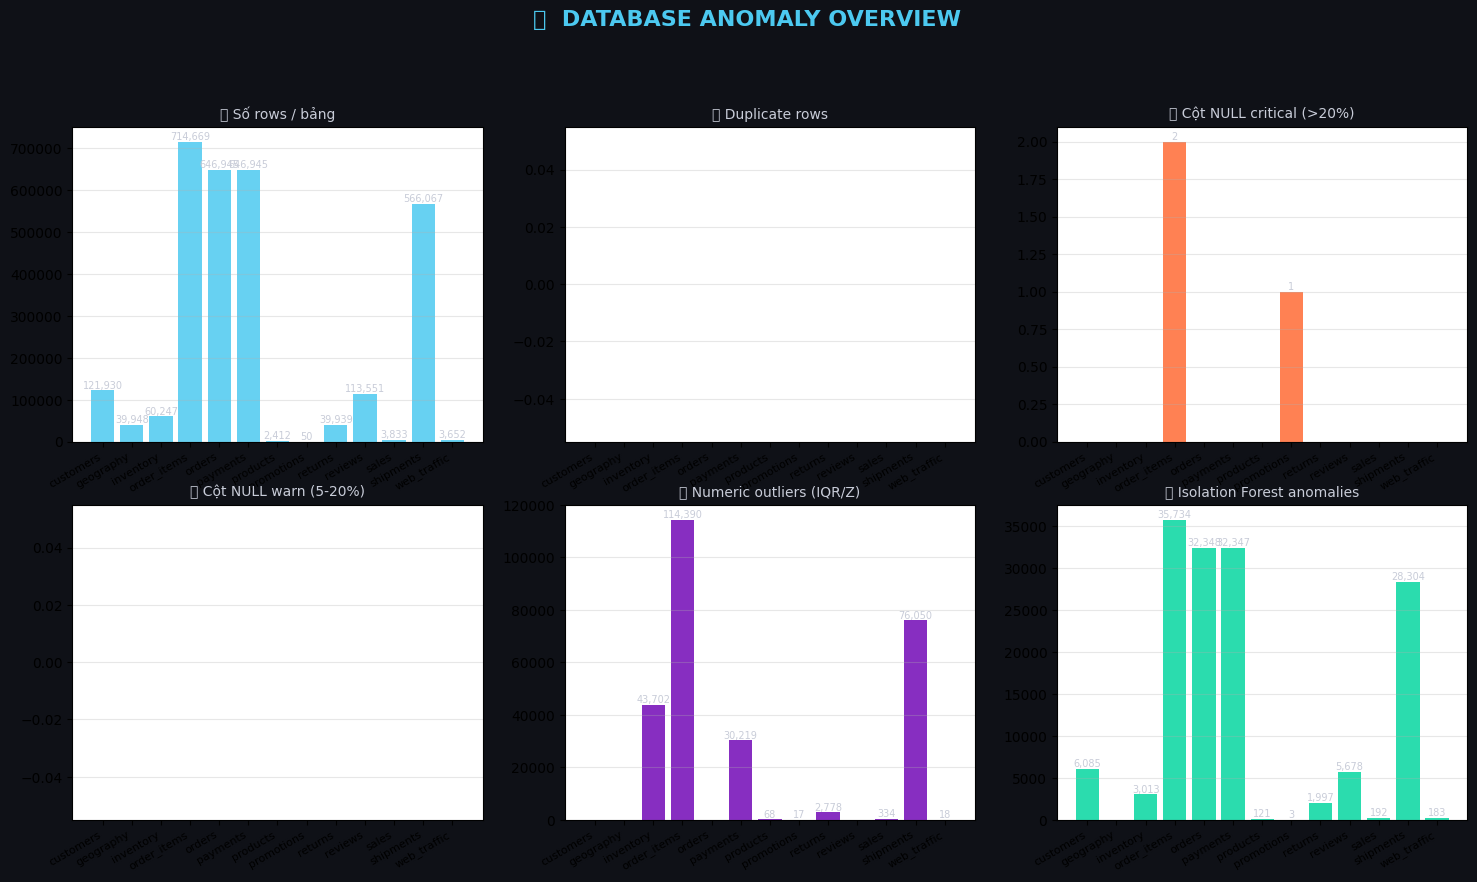

In [7]:
# ============================================================
# 📊 Overview dashboard
# ============================================================

def build_summary_df(results):
    rows = []
    for tbl, r in results.items():
        total_num_outliers = sum(v['n_total_outliers'] for v in r['num_outliers'].values())
        critical_nulls  = r['nulls']['level'].eq('CRITICAL').sum()
        warn_nulls      = r['nulls']['level'].eq('WARN').sum()
        rows.append({
            'Table'            : tbl,
            'Rows'             : r['n_rows'],
            'Cols'             : r['n_cols'],
            'Duplicates'       : r['duplicates']['n_duplicates'],
            'Dup %'            : r['duplicates']['pct'],
            'Null-Critical cols': critical_nulls,
            'Null-Warn cols'   : warn_nulls,
            'Num Outliers'     : total_num_outliers,
            'Iso Anomalies'    : len(r['iso_idx']) if r['iso_idx'] is not None else 0,
        })
    return pd.DataFrame(rows)


summary = build_summary_df(results)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('🔍  DATABASE ANOMALY OVERVIEW', fontsize=16, fontweight='bold', color='#4cc9f0', y=1.01)
fig.patch.set_facecolor('#0f1117')

def bar(ax, x, y, title, color='#4cc9f0', xlabel='', rotate=False):
    bars = ax.bar(x, y, color=color, edgecolor='none', alpha=0.85)
    ax.set_title(title, color='#c8ccd8', fontsize=10)
    ax.set_xlabel(xlabel, color='#8b92a5', fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x()+b.get_width()/2, h, f'{h:,.0f}',
                    ha='center', va='bottom', fontsize=7, color='#c8ccd8')
    if rotate:
        ax.set_xticklabels(x, rotation=30, ha='right', fontsize=8)

bar(axes[0,0], summary['Table'], summary['Rows'],
    '📦 Số rows / bảng', '#4cc9f0', rotate=True)
bar(axes[0,1], summary['Table'], summary['Duplicates'],
    '👥 Duplicate rows', '#f72585', rotate=True)
bar(axes[0,2], summary['Table'], summary['Null-Critical cols'],
    '🔴 Cột NULL critical (>20%)', '#ff6b35', rotate=True)
bar(axes[1,0], summary['Table'], summary['Null-Warn cols'],
    '🟡 Cột NULL warn (5-20%)', '#ffd166', rotate=True)
bar(axes[1,1], summary['Table'], summary['Num Outliers'],
    '📈 Numeric outliers (IQR/Z)', '#7209b7', rotate=True)
bar(axes[1,2], summary['Table'], summary['Iso Anomalies'],
    '🌲 Isolation Forest anomalies', '#06d6a0', rotate=True)

# Bảng tổng hợp
print('\n📋 SUMMARY TABLE')
display(summary.style
    .format({'Rows': '{:,}', 'Dup %': '{:.1f}%'})
    .background_gradient(subset=['Duplicates','Null-Critical cols','Num Outliers','Iso Anomalies'],
                         cmap='Reds')
    .set_table_styles([{'selector':'th','props':'background:#1a1d27;color:#4cc9f0;padding:6px'}])
)

---
## 🔎 CELL 6 – Chi tiết từng bảng

### 📄 Bảng: `customers`

### 📄 Bảng: `geography`

### 📄 Bảng: `inventory`

### 📄 Bảng: `order_items`

### 📄 Bảng: `orders`

...

### 📄 Bảng: `returns`

### 📄 Bảng: `reviews`

### 📄 Bảng: `sales`

### 📄 Bảng: `shipments`

### 📄 Bảng: `web_traffic`

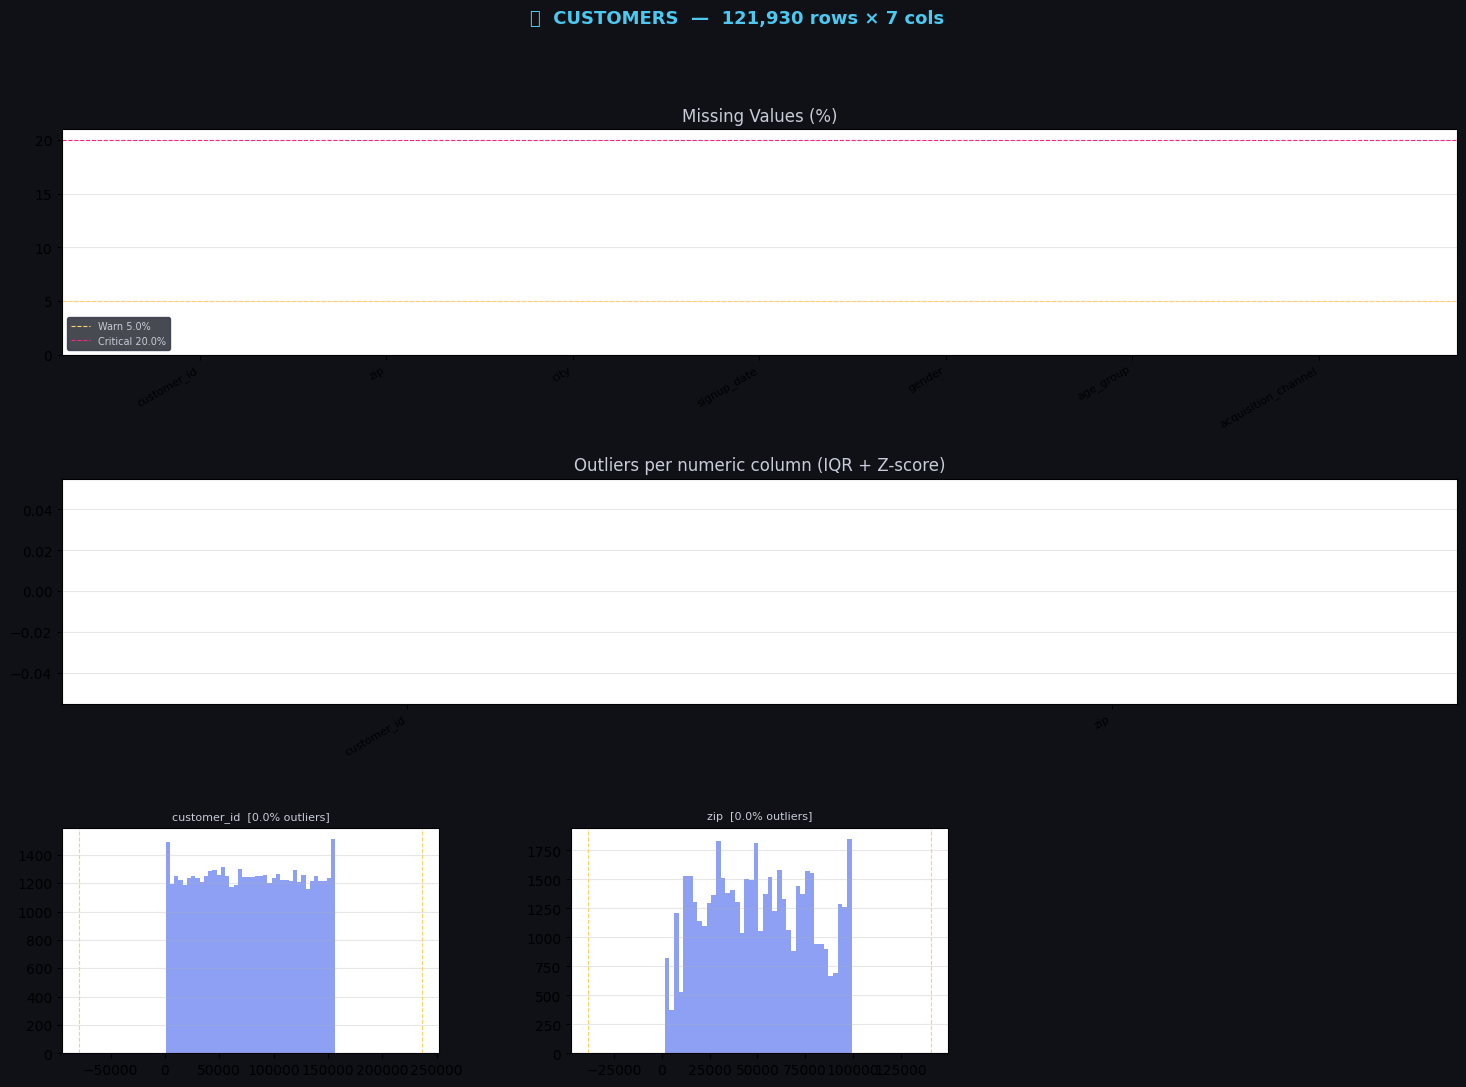

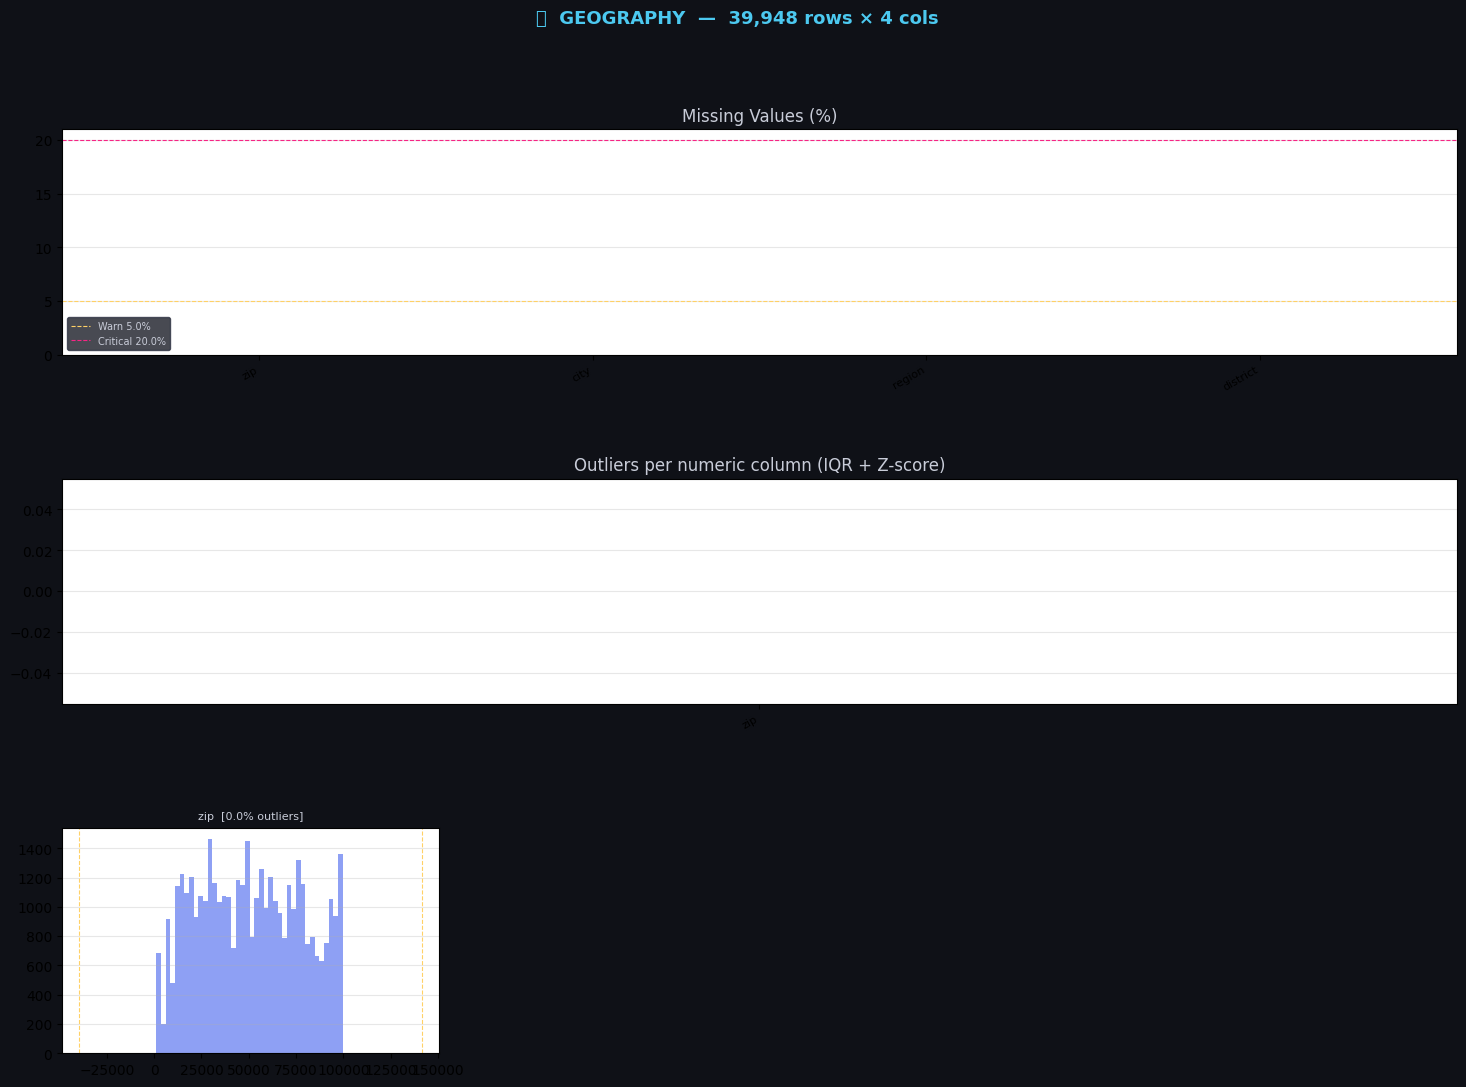

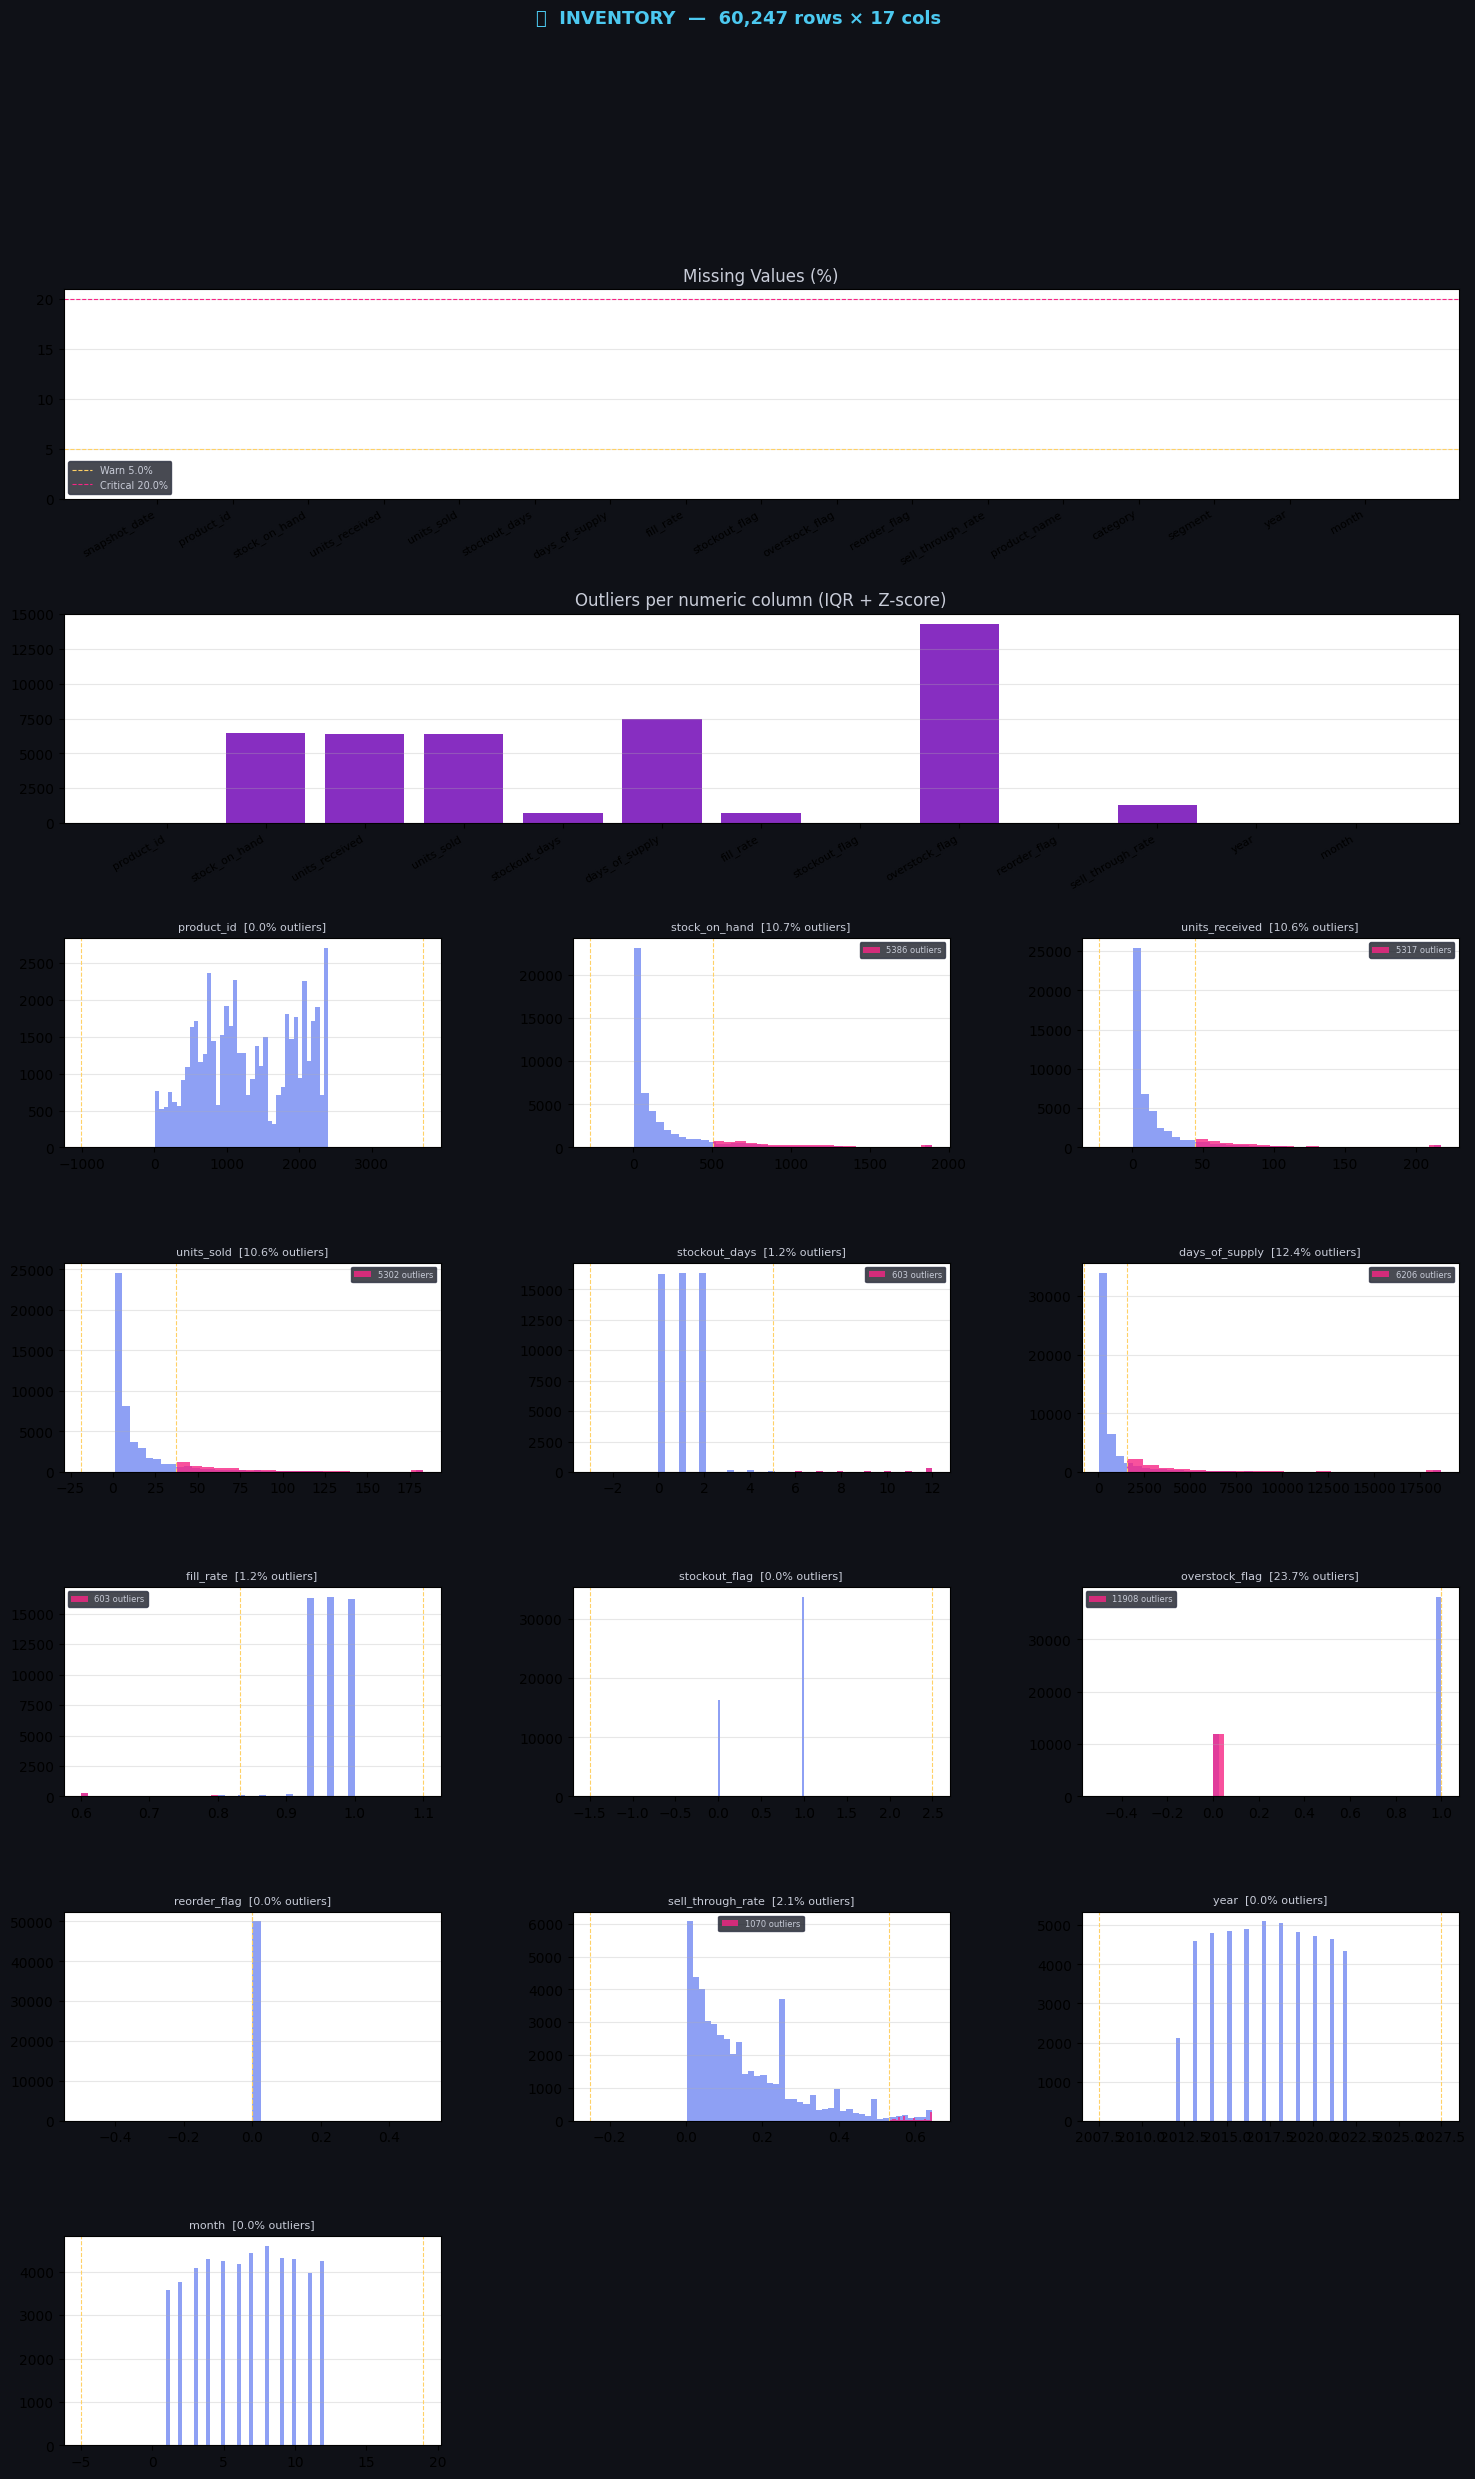

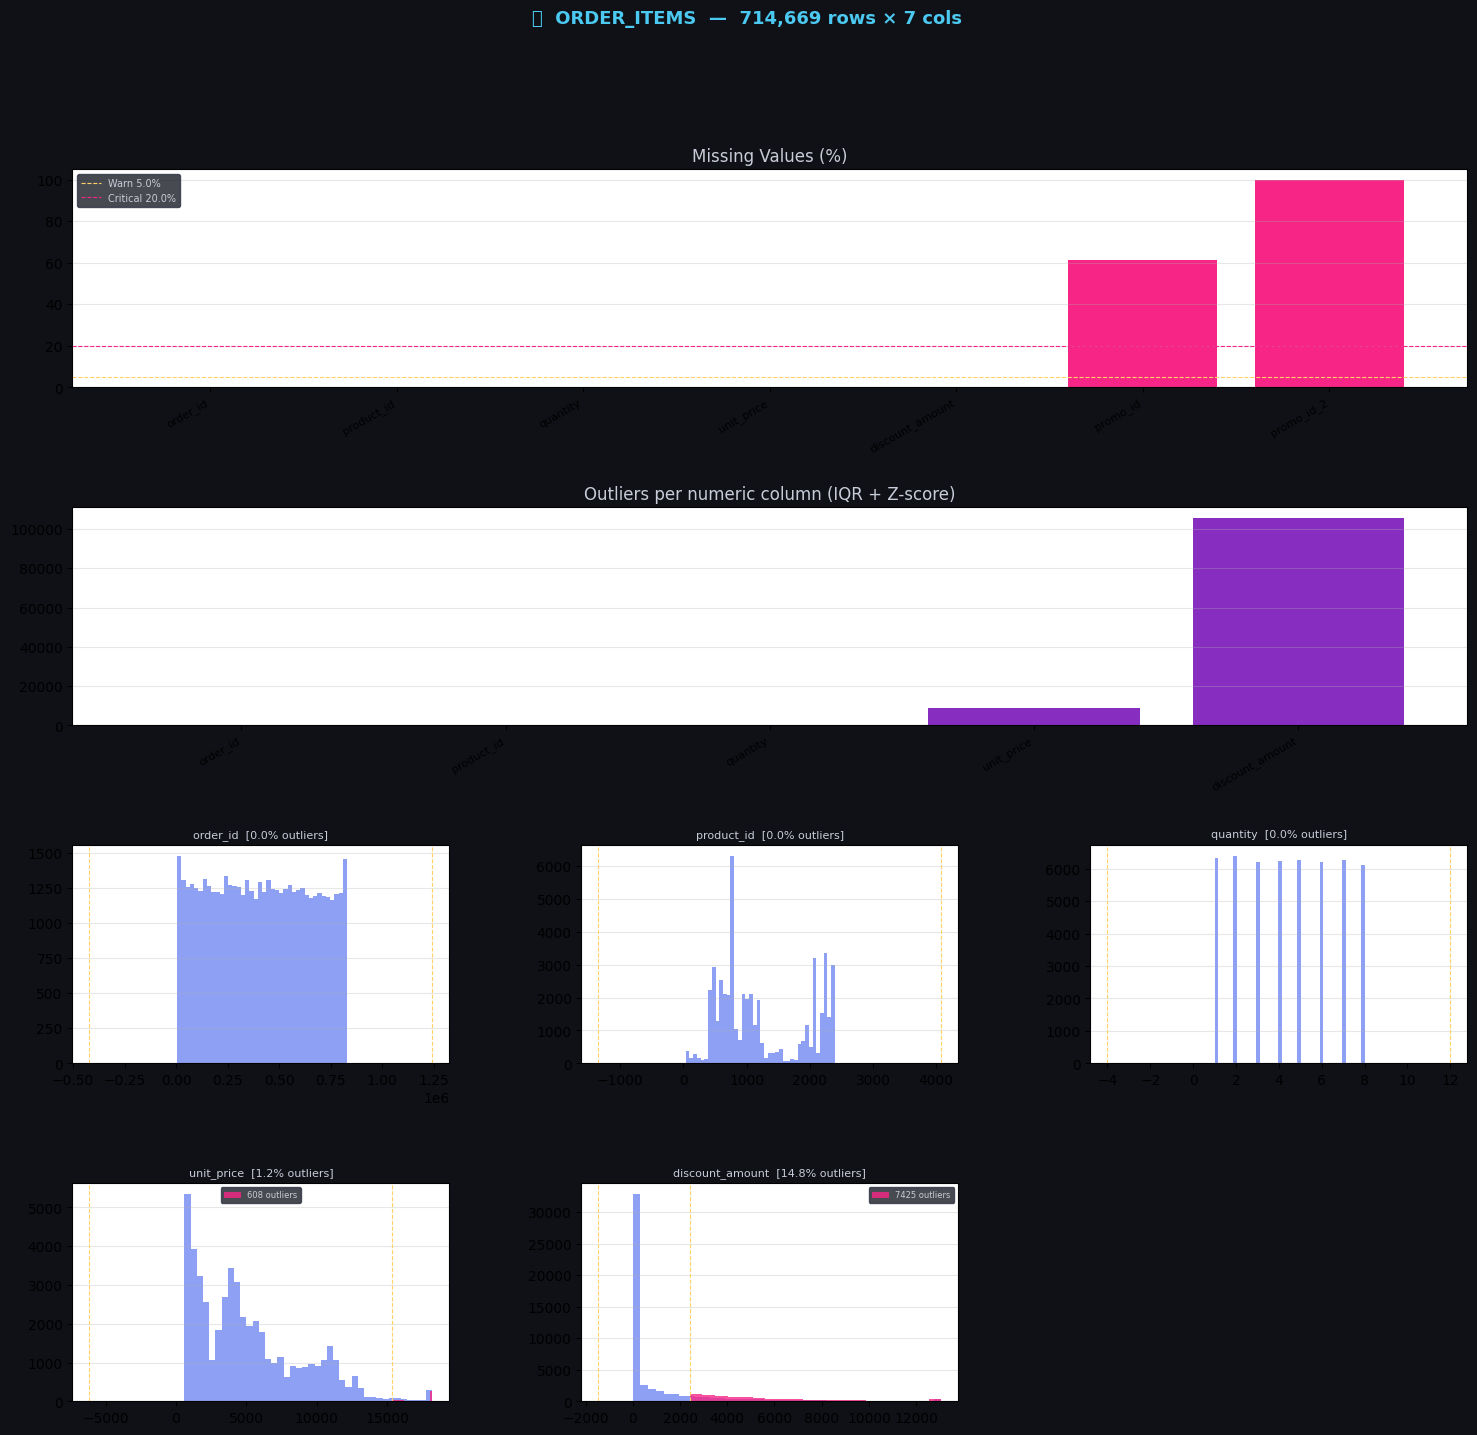

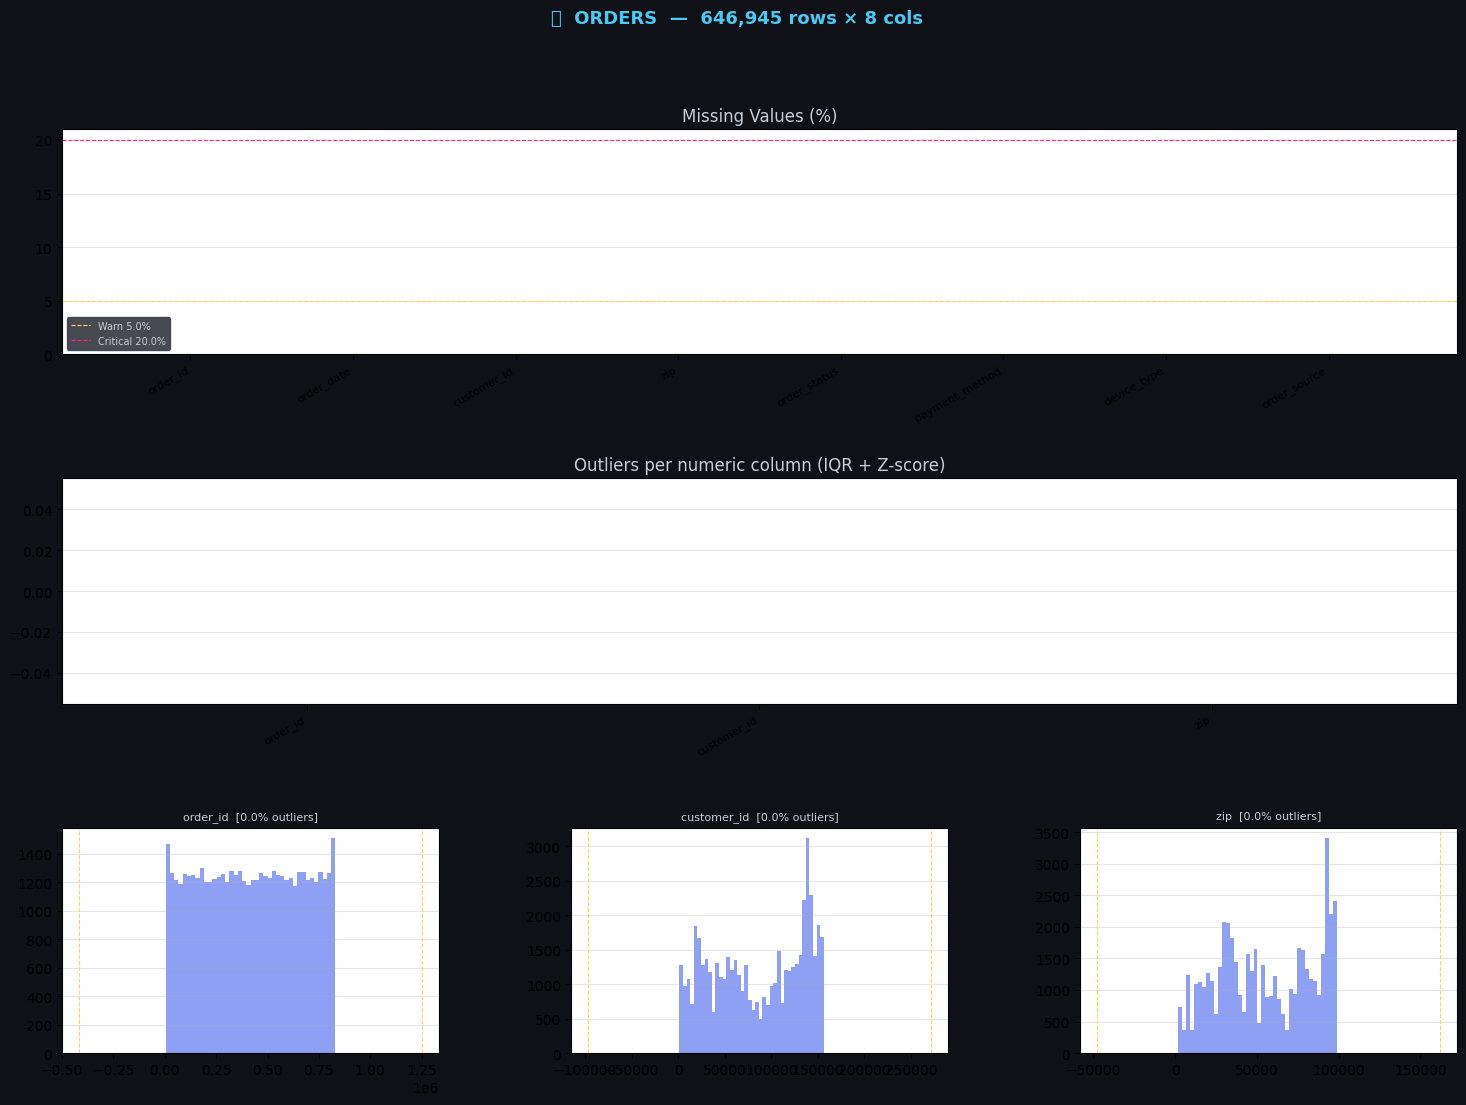

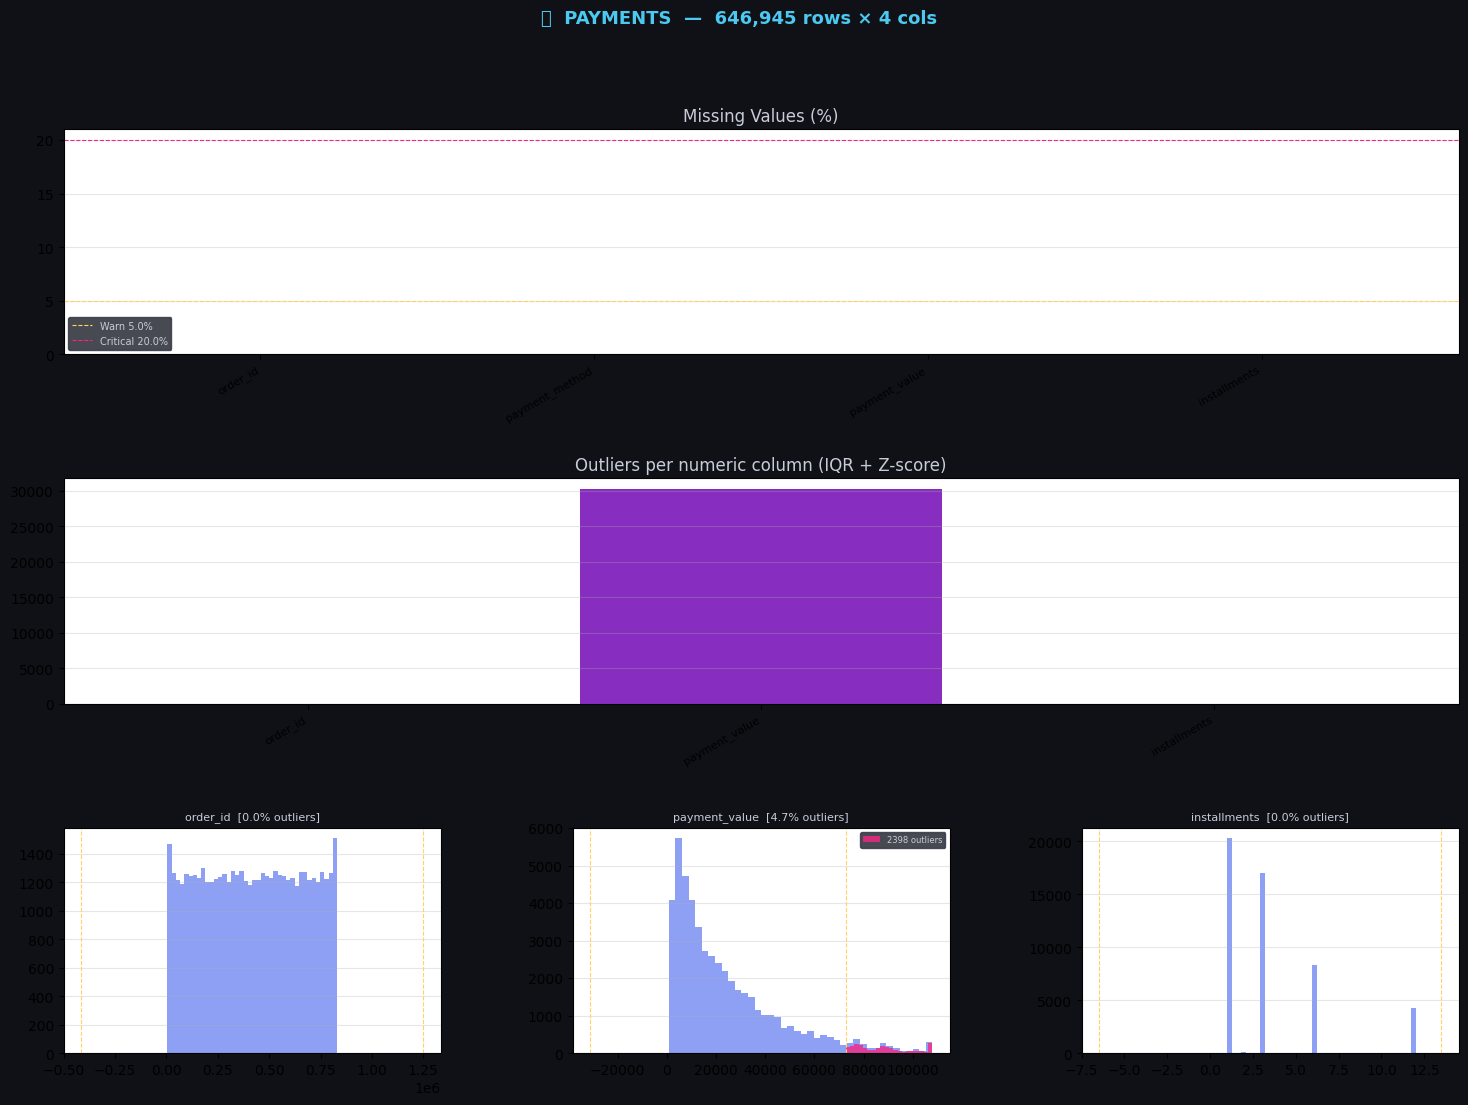

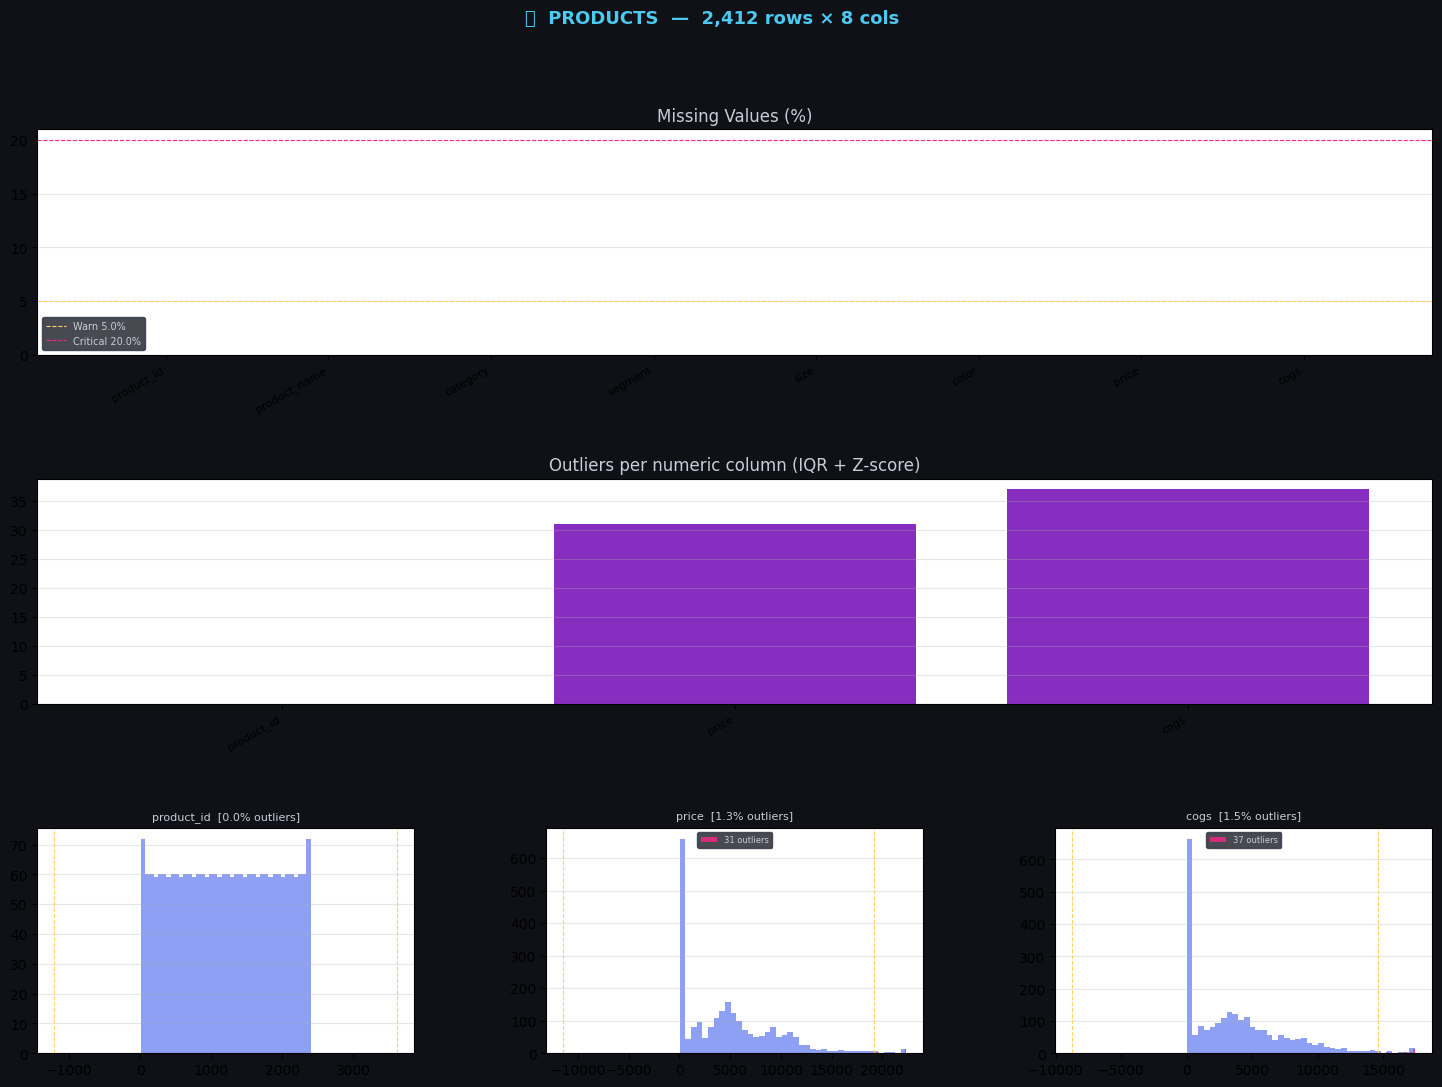

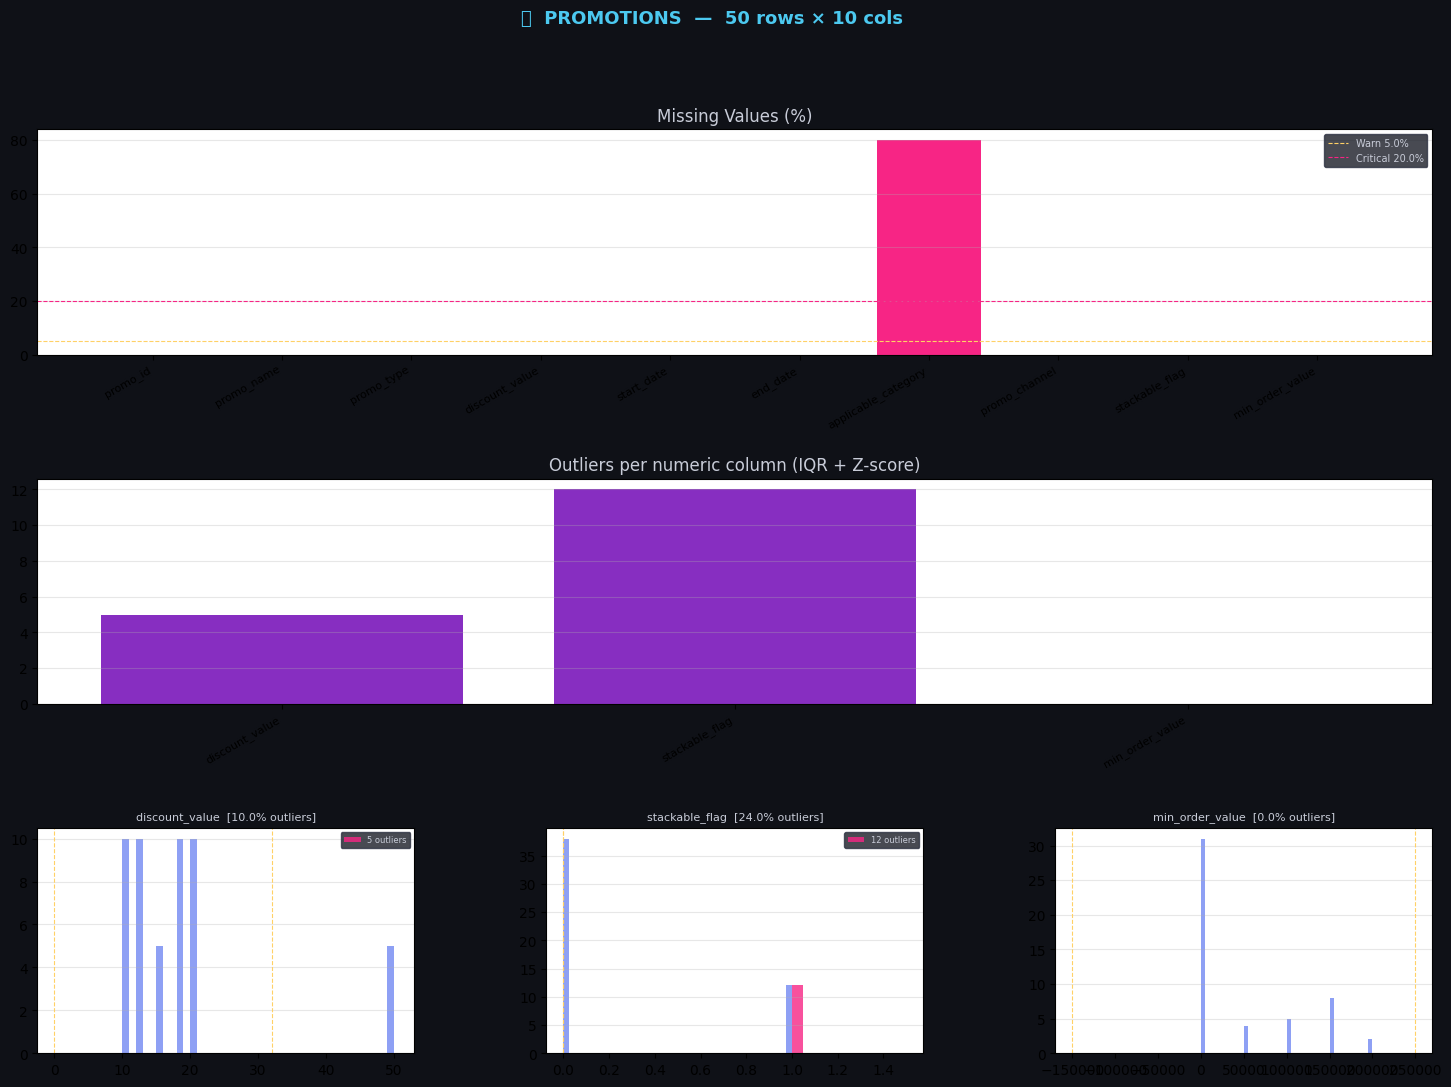

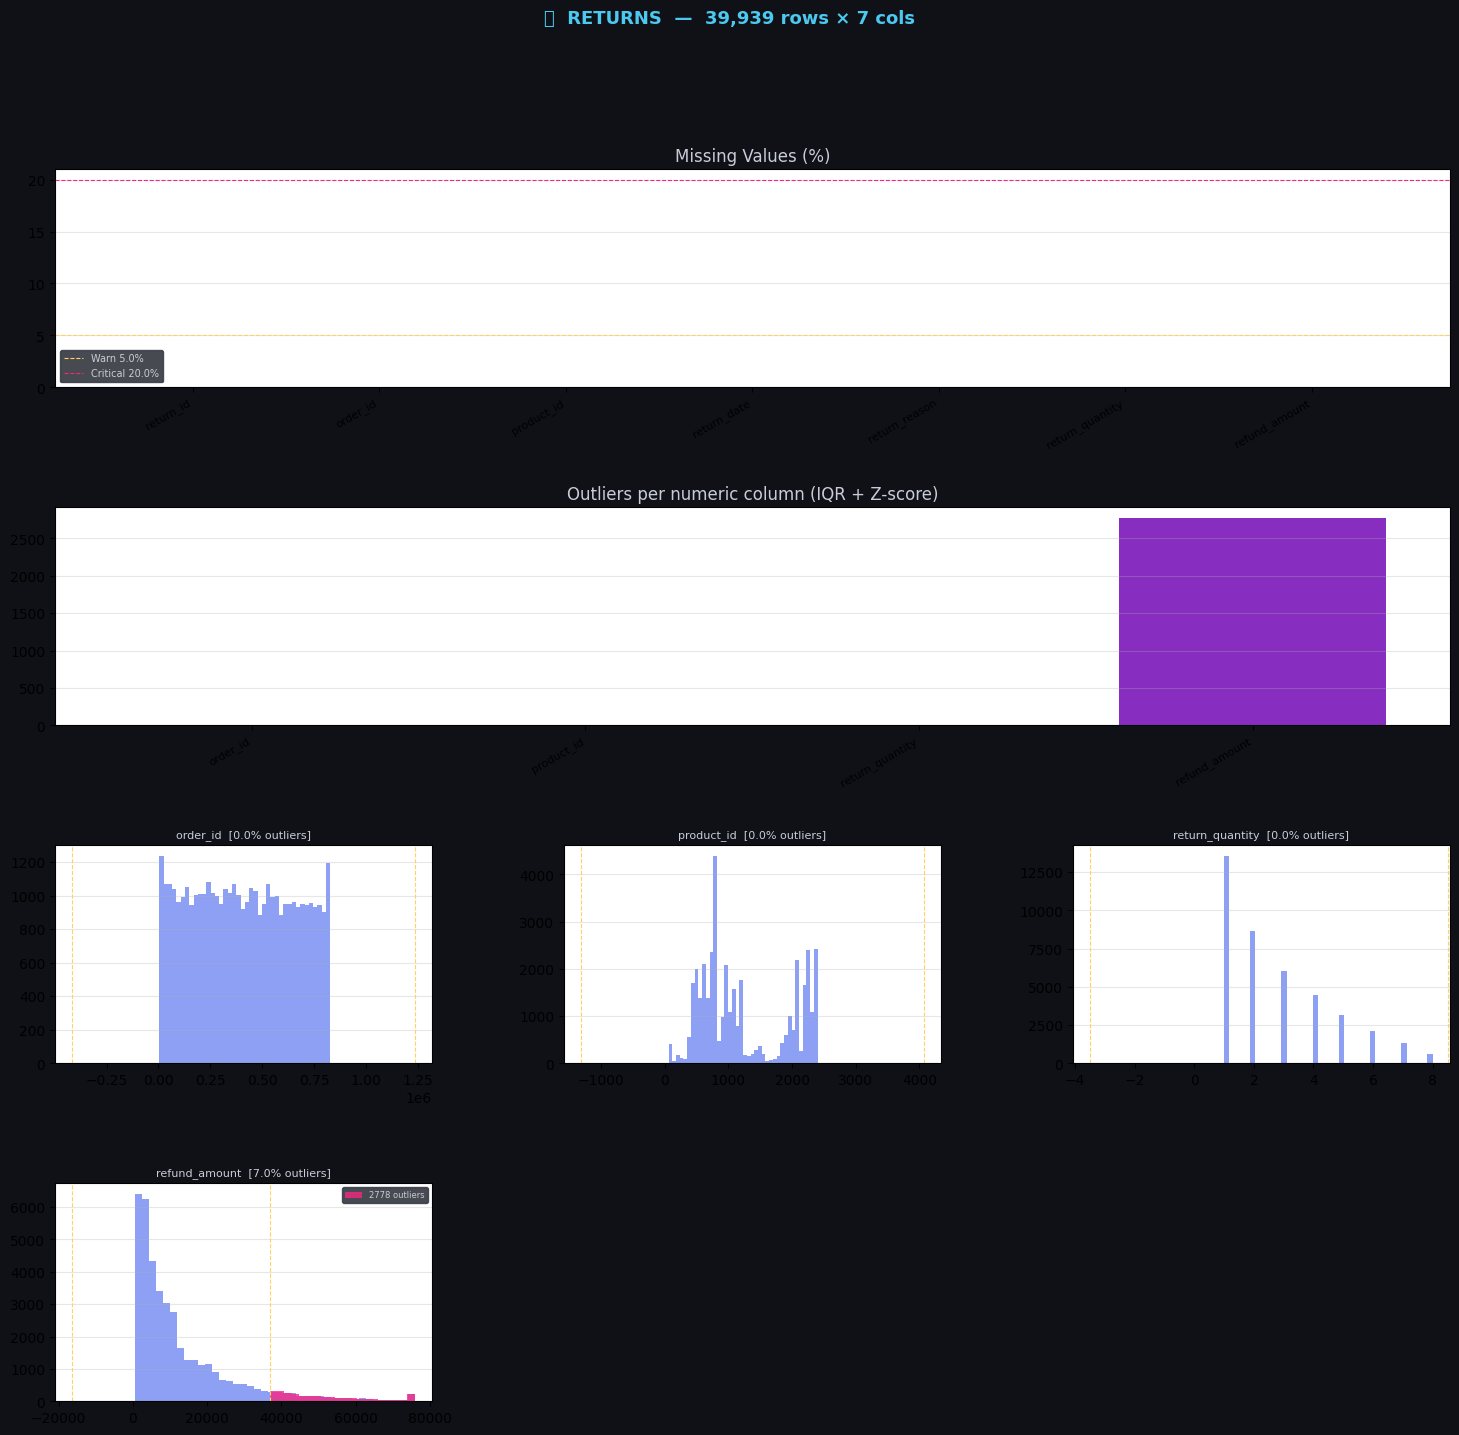

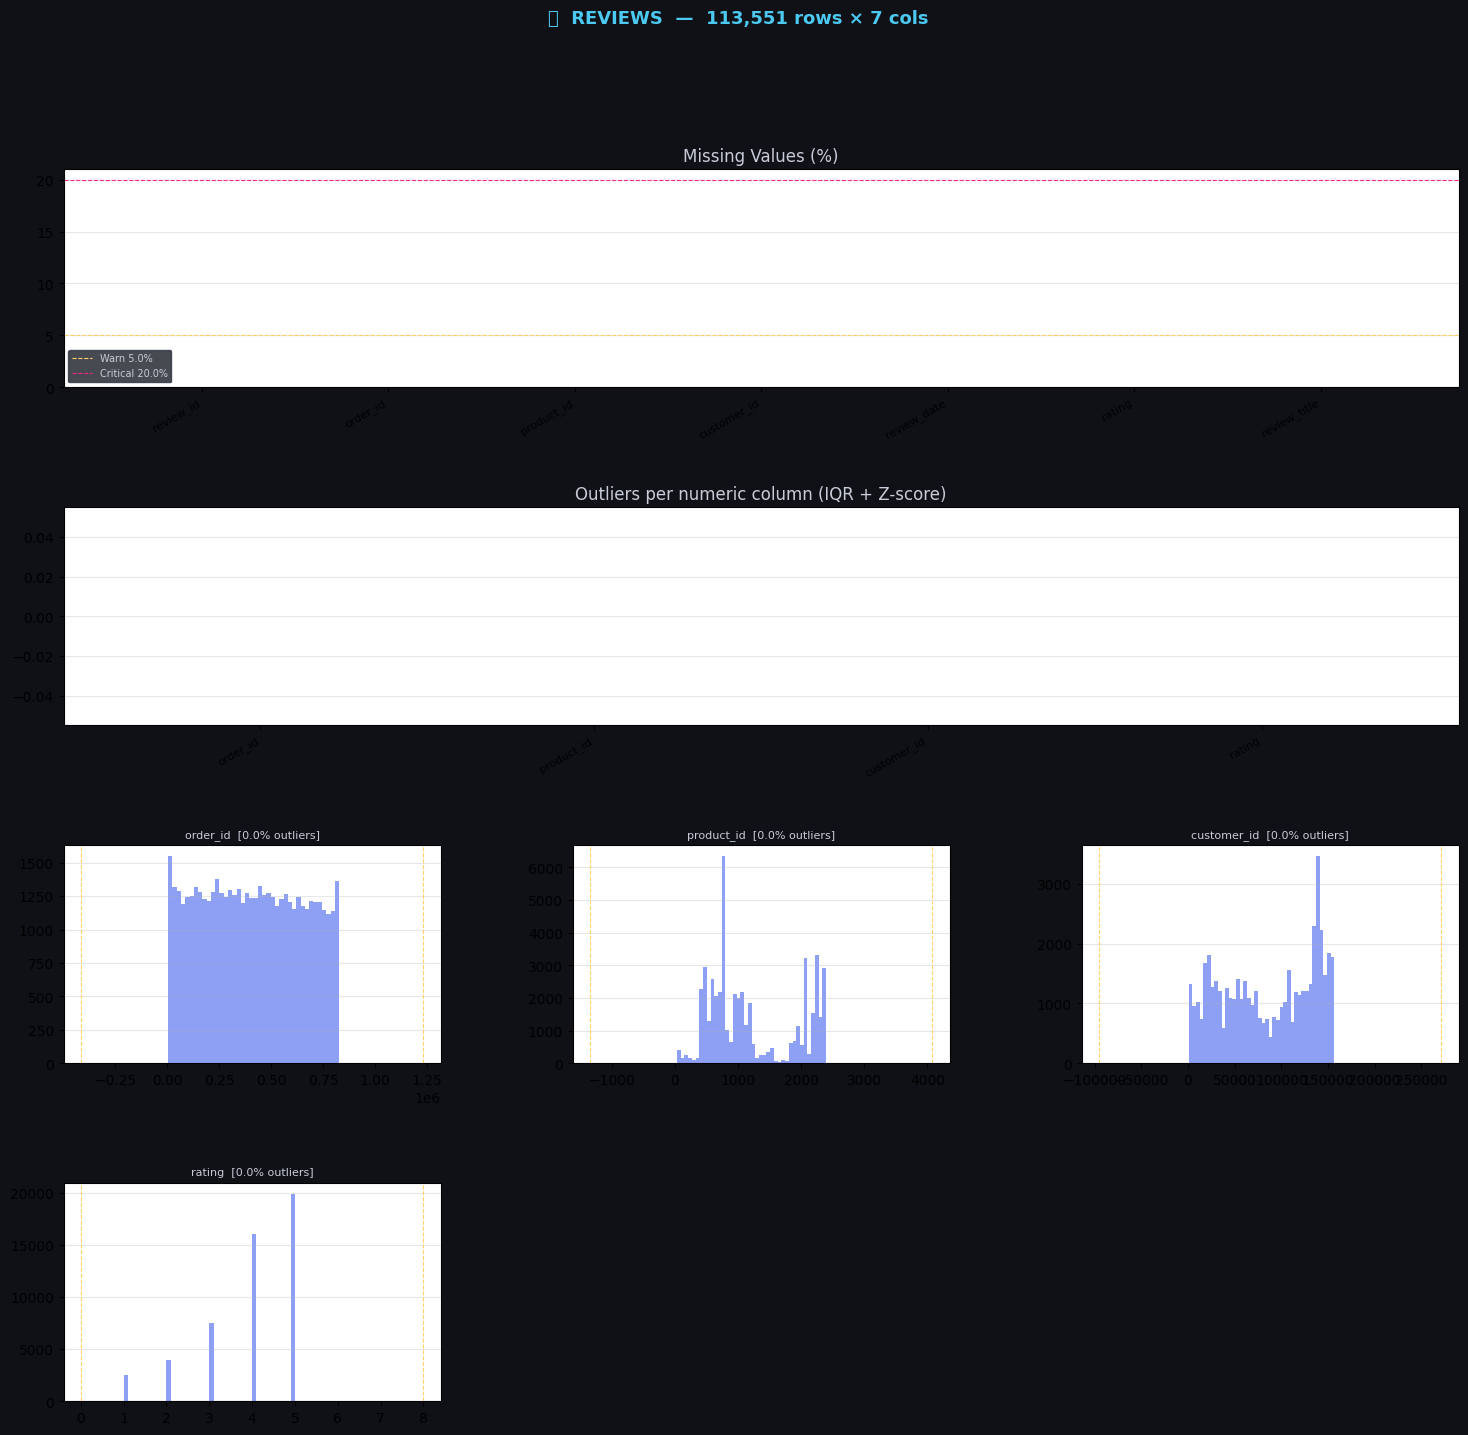

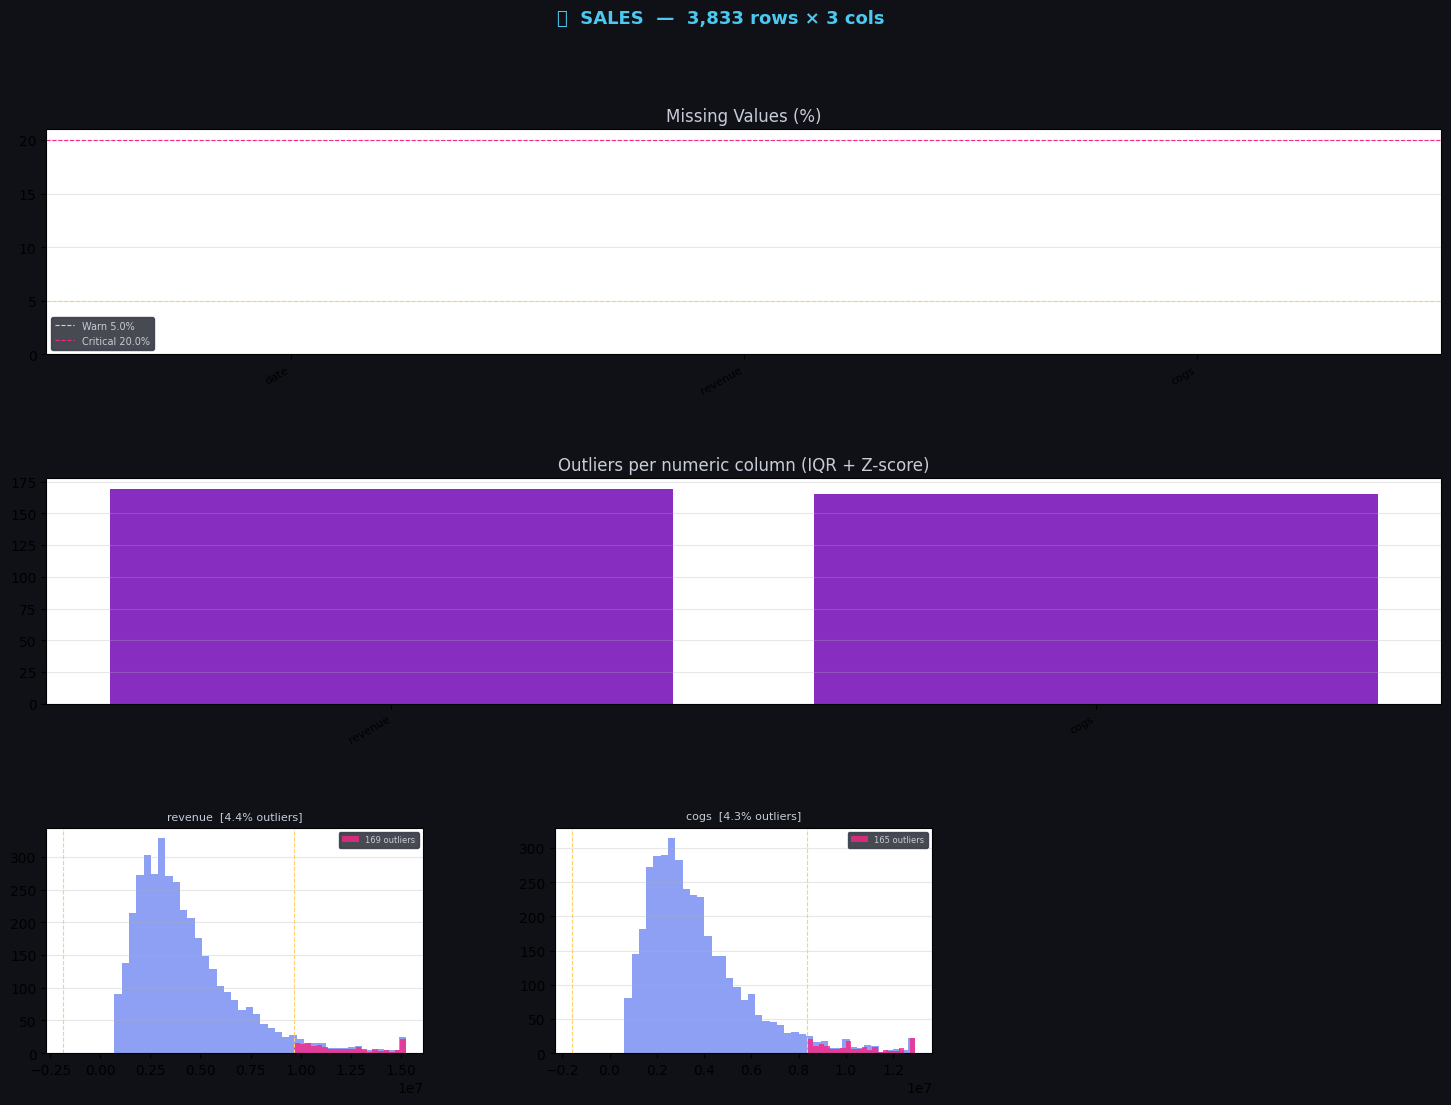

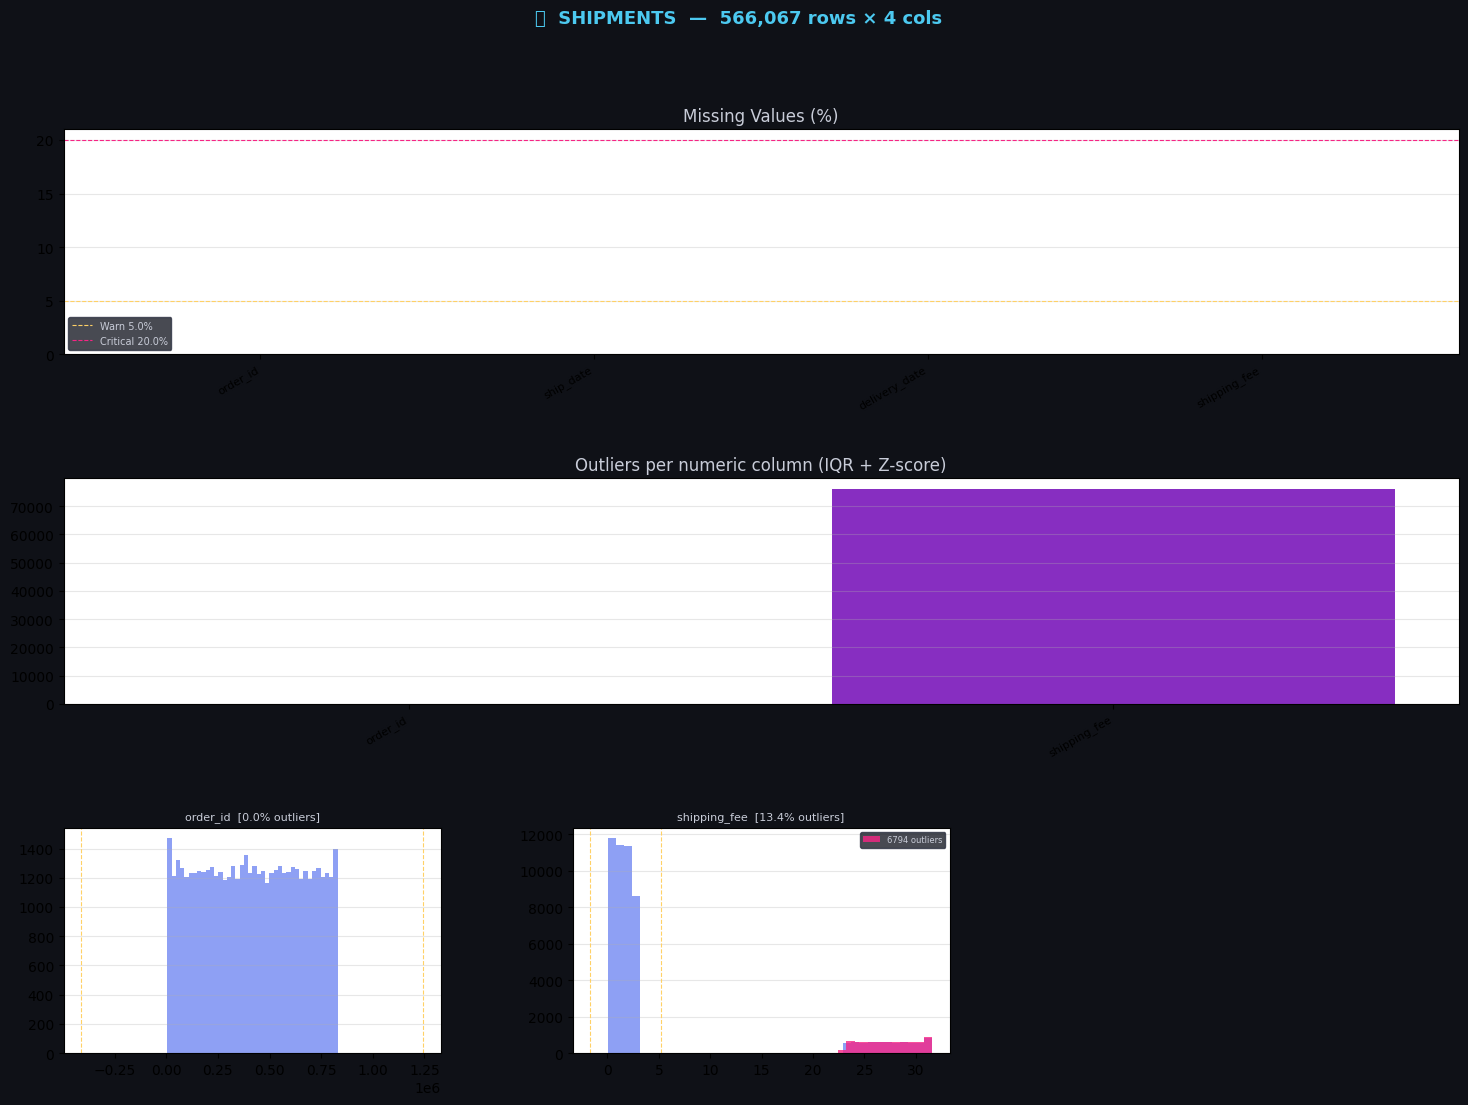

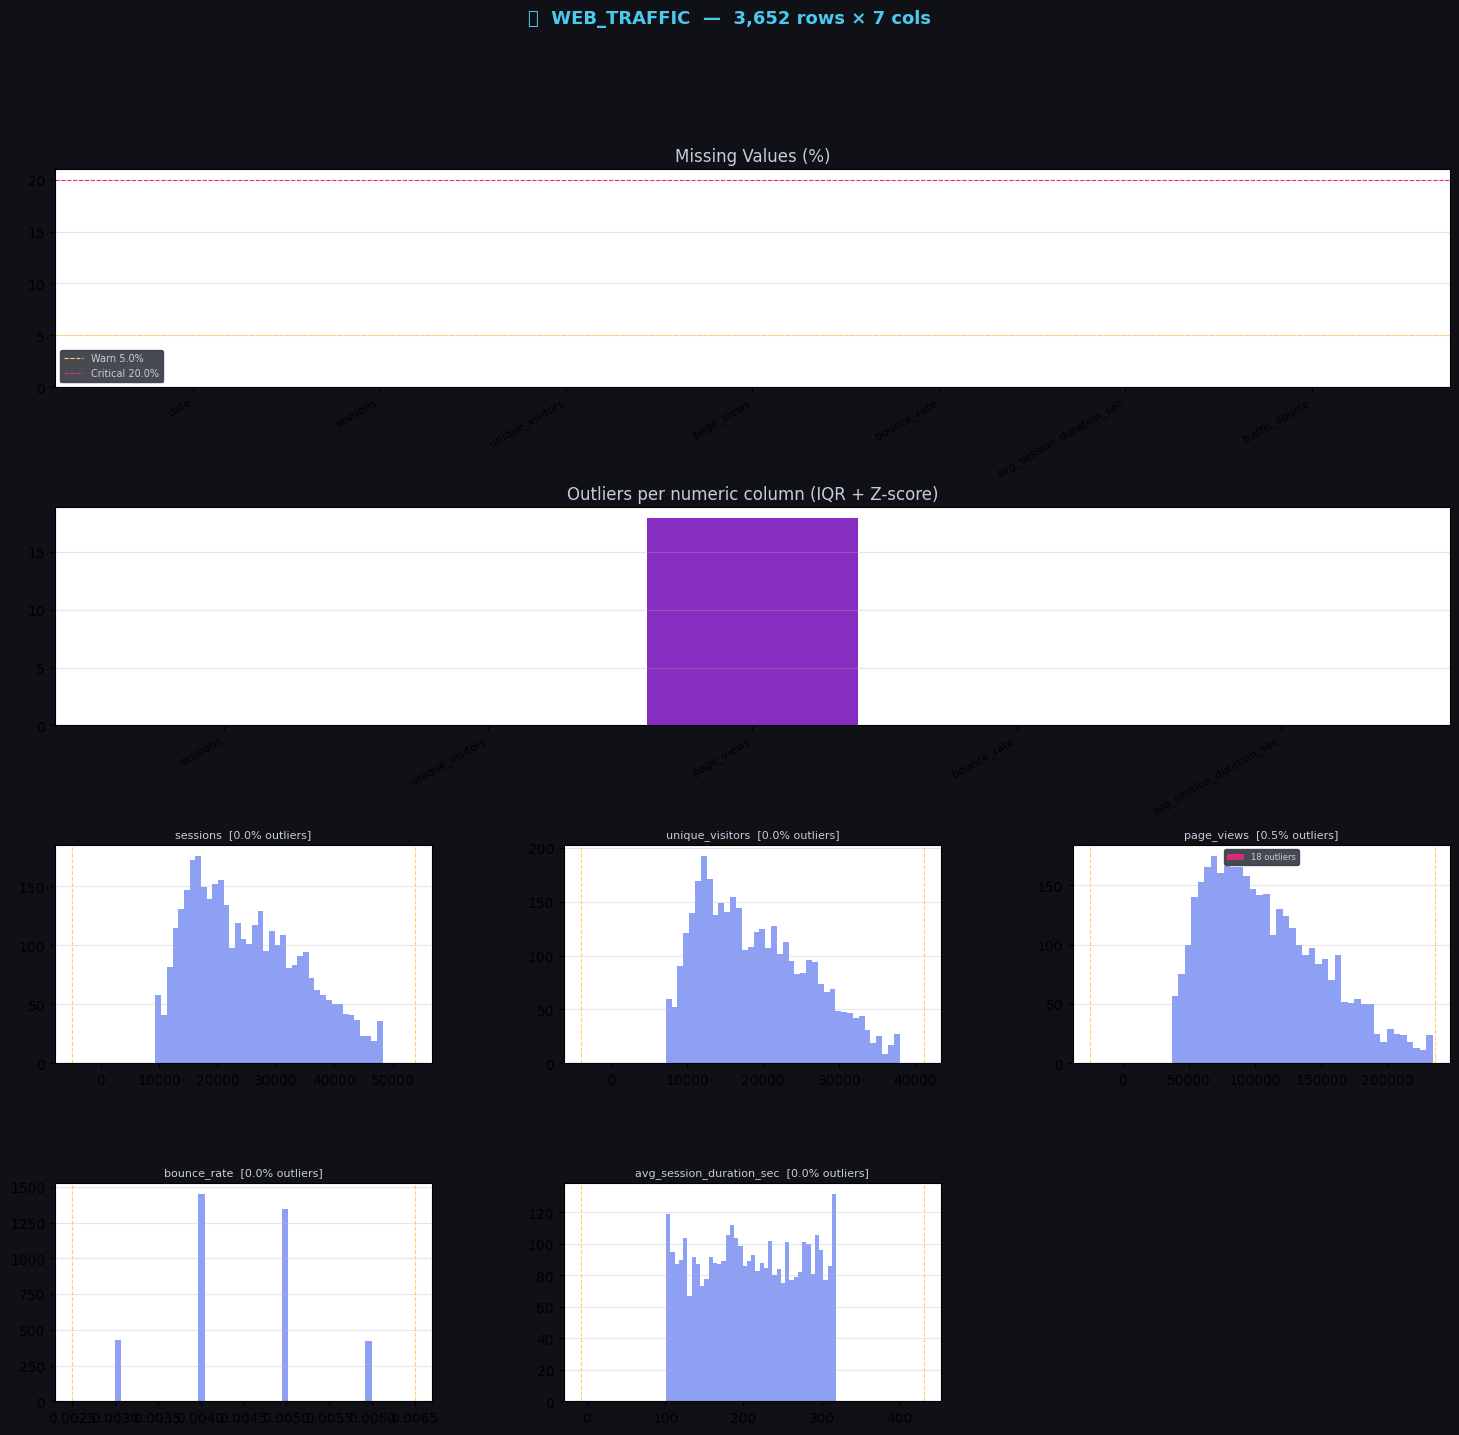

In [8]:
# ============================================================
# 🔎 Per-table deep dive
# ============================================================

def plot_table_detail(r, cfg):
    tbl = r['table_name']
    num_cols = r['num_cols']
    df_s = r['df_sample']

    # --- NULL heatmap ---
    null_df = r['nulls'].set_index('column')

    # --- Numeric outlier chart ---
    n_num = len(num_cols)
    if n_num == 0:
        print(f'   [{tbl}] Không có cột numeric, bỏ qua chart.')
        return

    n_rows_plot = 2 + (n_num + 2) // 3
    fig = plt.figure(figsize=(18, 4 * n_rows_plot), facecolor='#0f1117')
    fig.suptitle(f'📊  {tbl.upper()}  —  {r["n_rows"]:,} rows × {r["n_cols"]} cols',
                 fontsize=13, color='#4cc9f0', fontweight='bold')

    gs = gridspec.GridSpec(n_rows_plot, 3, figure=fig, hspace=0.55, wspace=0.35)

    # ── Row 0: NULL bar chart ──
    ax_null = fig.add_subplot(gs[0, :])
    colors_null = ['#f72585' if l == 'CRITICAL' else '#ffd166' if l == 'WARN' else '#2d3142'
                   for l in null_df['level']]
    ax_null.bar(null_df.index, null_df['null_pct'], color=colors_null, edgecolor='none')
    ax_null.axhline(cfg['null_warn_pct'],     color='#ffd166', ls='--', lw=0.8, label=f"Warn {cfg['null_warn_pct']}%")
    ax_null.axhline(cfg['null_critical_pct'], color='#f72585', ls='--', lw=0.8, label=f"Critical {cfg['null_critical_pct']}%")
    ax_null.set_title('Missing Values (%)', color='#c8ccd8')
    ax_null.set_xticklabels(null_df.index, rotation=30, ha='right', fontsize=8)
    ax_null.legend(fontsize=7, facecolor='#1a1d27', edgecolor='#2d3142', labelcolor='#c8ccd8')
    ax_null.grid(axis='y', alpha=0.3)

    # ── Row 1: Outlier count bar ──
    ax_out = fig.add_subplot(gs[1, :])
    out_data = {col: v['n_total_outliers'] for col, v in r['num_outliers'].items()}
    if out_data:
        ax_out.bar(list(out_data.keys()), list(out_data.values()), color='#7209b7', edgecolor='none', alpha=0.85)
        ax_out.set_title('Outliers per numeric column (IQR + Z-score)', color='#c8ccd8')
        ax_out.set_xticklabels(list(out_data.keys()), rotation=30, ha='right', fontsize=8)
        ax_out.grid(axis='y', alpha=0.3)

    # ── Rows 2+: Distribution plots ──
    for i, col in enumerate(num_cols):
        row_i = 2 + i // 3
        col_i = i  % 3
        ax = fig.add_subplot(gs[row_i, col_i])

        data = df_s[col].dropna()
        if len(data) == 0:
            ax.set_visible(False)
            continue

        ov = r['num_outliers'].get(col, {})
        mask = ov.get('outlier_mask', pd.Series(False, index=df_s.index))
        mask_s = mask.reindex(df_s.index, fill_value=False)

        normal_data  = df_s.loc[~mask_s, col].dropna()
        outlier_data = df_s.loc[mask_s,  col].dropna()

        # clip extreme values for display
        p1, p99 = data.quantile(0.005), data.quantile(0.995)
        clipped = data.clip(p1, p99)

        ax.hist(clipped, bins=40, color='#4361ee', alpha=0.6, edgecolor='none')
        if len(outlier_data) > 0:
            ax.hist(outlier_data.clip(p1,p99), bins=20, color='#f72585', alpha=0.8, label=f'{len(outlier_data)} outliers')
        if ov:
            ax.axvline(ov['iqr_lower'], color='#ffd166', ls='--', lw=0.8)
            ax.axvline(ov['iqr_upper'], color='#ffd166', ls='--', lw=0.8)

        pct_str = f"{ov.get('outlier_pct', 0):.1f}%" if ov else ''
        ax.set_title(f'{col}  [{pct_str} outliers]', fontsize=8, color='#c8ccd8')
        if len(outlier_data) > 0:
            ax.legend(fontsize=6, facecolor='#1a1d27', edgecolor='#2d3142', labelcolor='#c8ccd8')
        ax.grid(axis='y', alpha=0.3)


# Chạy cho tất cả bảng
for tbl, r in results.items():
    display(Markdown(f'### 📄 Bảng: `{tbl}`'))
    plot_table_detail(r, CFG)

---
## 📋 CELL 7 – Xem các row bất thường cụ thể

In [9]:
# ============================================================
# 📋 Drill-down: xem các row bất thường
# ============================================================

print('=' * 70)
print('  ANOMALOUS ROWS DETAIL')
print('=' * 70)

for tbl, r in results.items():
    df = r['df']
    anomaly_union = pd.Series(False, index=df.index)

    # Tổng hợp tất cả outlier masks
    for col, ov in r['num_outliers'].items():
        anomaly_union |= ov['outlier_mask'].reindex(df.index, fill_value=False)

    # Thêm Isolation Forest
    if r['iso_idx'] is not None:
        anomaly_union |= df.index.isin(r['iso_idx'])

    # Thêm full-row duplicate
    dup_mask = df.duplicated(keep=False)
    anomaly_union |= dup_mask

    n_anomalous = anomaly_union.sum()
    if n_anomalous == 0:
        print(f'\n✅ [{tbl}] Không phát hiện row bất thường')
        continue

    display(Markdown(f'### 🔴 `{tbl}` — {n_anomalous:,} anomalous rows'))
    anom_df = df[anomaly_union].head(CFG['display_rows']).copy()
    display(anom_df.style.highlight_null('#ff000040')
            .set_table_styles([{'selector':'th','props':'background:#1a1d27;color:#f72585;padding:5px'}]))

  ANOMALOUS ROWS DETAIL


### 🔴 `customers` — 6,085 anomalous rows

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30 00:00:00,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27 00:00:00,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24 00:00:00,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29 00:00:00,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23 00:00:00,Male,55+,organic_search
5,6,15202,Phu Ly,2022-04-14 00:00:00,Female,25-34,organic_search
6,8,15202,Phu Ly,2015-09-11 00:00:00,Male,45-54,social_media
7,9,15202,Phu Ly,2020-02-14 00:00:00,Male,35-44,email_campaign
8,10,15202,Phu Ly,2014-03-03 00:00:00,Male,25-34,organic_search
9,11,15203,Viet Tri,2017-11-07 00:00:00,Male,35-44,organic_search



✅ [geography] Không phát hiện row bất thường


### 🔴 `inventory` — 28,014 anomalous rows

...

,date,revenue,cogs
29,2012-08-02 00:00:00,9692427.000000,7537501.150000
57,2012-08-30 00:00:00,10086534.100000,7950911.720000
241,2013-03-02 00:00:00,279813.940000,236576.310000
269,2013-03-30 00:00:00,11636994.380000,10600188.310000
270,2013-03-31 00:00:00,9455023.800000,8513517.850000
271,2013-04-01 00:00:00,10313848.230000,9188774.520000
299,2013-04-29 00:00:00,13160942.220000,10423989.710000
300,2013-04-30 00:00:00,11190466.860000,8842281.650000
301,2013-05-01 00:00:00,13051232.310000,10395426.510000
302,2013-05-02 00:00:00,11179665.290000,8989067.990000


### 🔴 `shipments` — 76,069 anomalous rows

,order_id,ship_date,delivery_date,shipping_fee
4,6,2012-07-09 00:00:00,2012-07-16 00:00:00,25.790000
20,29,2012-07-08 00:00:00,2012-07-14 00:00:00,23.040000
21,30,2012-07-07 00:00:00,2012-07-11 00:00:00,31.590000
26,36,2012-07-06 00:00:00,2012-07-09 00:00:00,25.470000
27,38,2012-07-06 00:00:00,2012-07-09 00:00:00,31.330000
42,62,2012-07-06 00:00:00,2012-07-13 00:00:00,25.420000
61,87,2012-07-05 00:00:00,2012-07-09 00:00:00,29.810000
62,88,2012-07-07 00:00:00,2012-07-09 00:00:00,29.960000
97,149,2012-07-08 00:00:00,2012-07-15 00:00:00,0.010000
98,152,2012-07-04 00:00:00,2012-07-09 00:00:00,31.700000


### 🔴 `web_traffic` — 183 anomalous rows

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01 00:00:00,9760,7253,39093,0.005000,102.900000,organic_search
3,2013-01-04 00:00:00,9973,8063,53078,0.006000,151.800000,direct
7,2013-01-08 00:00:00,9456,7459,31482,0.004000,192.400000,paid_search
8,2013-01-09 00:00:00,9162,7108,46717,0.004000,312.800000,organic_search
11,2013-01-12 00:00:00,8730,6136,33336,0.004000,193.300000,paid_search
12,2013-01-13 00:00:00,8818,6863,35427,0.004000,308.800000,paid_search
13,2013-01-14 00:00:00,8230,6203,35402,0.004000,301.500000,paid_search
14,2013-01-15 00:00:00,8102,6179,39490,0.004000,314.000000,direct
15,2013-01-16 00:00:00,9373,7503,37034,0.004000,284.400000,paid_search
18,2013-01-19 00:00:00,8746,6138,33440,0.005000,223.100000,organic_search


---
## 🌡️ CELL 8 – Heatmap tương quan anomaly giữa các bảng

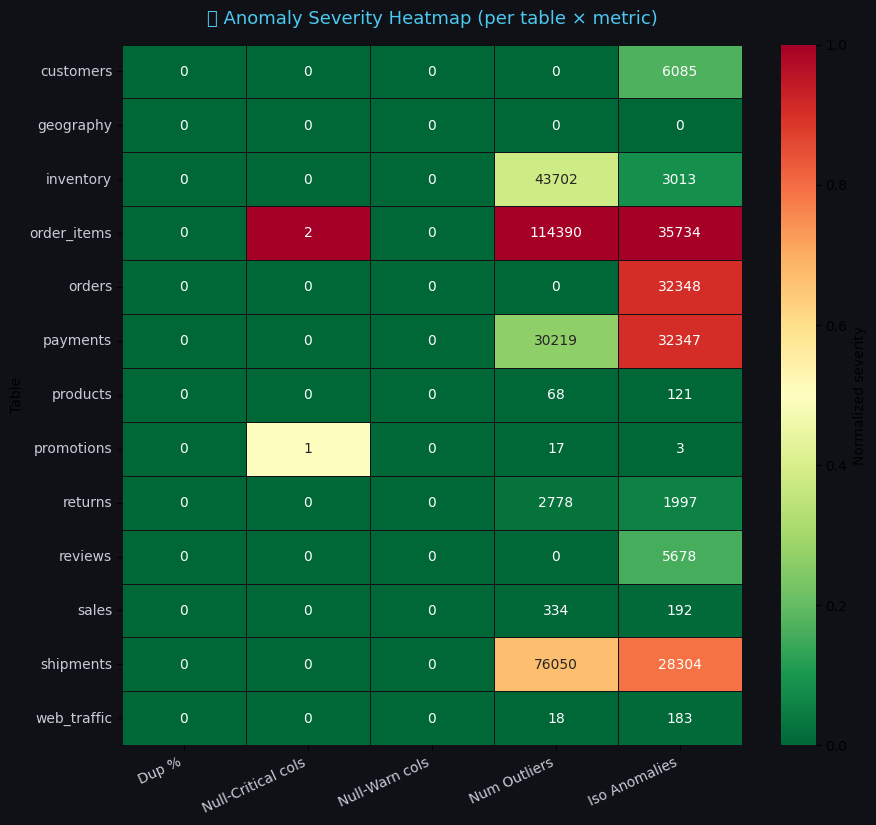

In [10]:
# ============================================================
# 🌡️ Cross-table anomaly severity heatmap
# ============================================================

metrics = ['Dup %', 'Null-Critical cols', 'Null-Warn cols', 'Num Outliers', 'Iso Anomalies']
heat_data = summary.set_index('Table')[metrics].copy()

# Normalize mỗi cột về [0,1]
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, max(4, len(tables_name)*0.7)), facecolor='#0f1117')
sns.heatmap(
    heat_norm,
    annot=heat_data.values,
    fmt='.0f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    linecolor='#0f1117',
    ax=ax,
    cbar_kws={'label': 'Normalized severity'},
)
ax.set_title('🌡️ Anomaly Severity Heatmap (per table × metric)',
             color='#4cc9f0', fontsize=13, pad=15)
ax.set_xticklabels(metrics, rotation=25, ha='right', color='#c8ccd8')
ax.set_yticklabels(ax.get_yticklabels(), color='#c8ccd8', rotation=0)
plt.show()

---
## 🎯 CELL 10 – Tùy chọn: Deep dive vào một bảng cụ thể

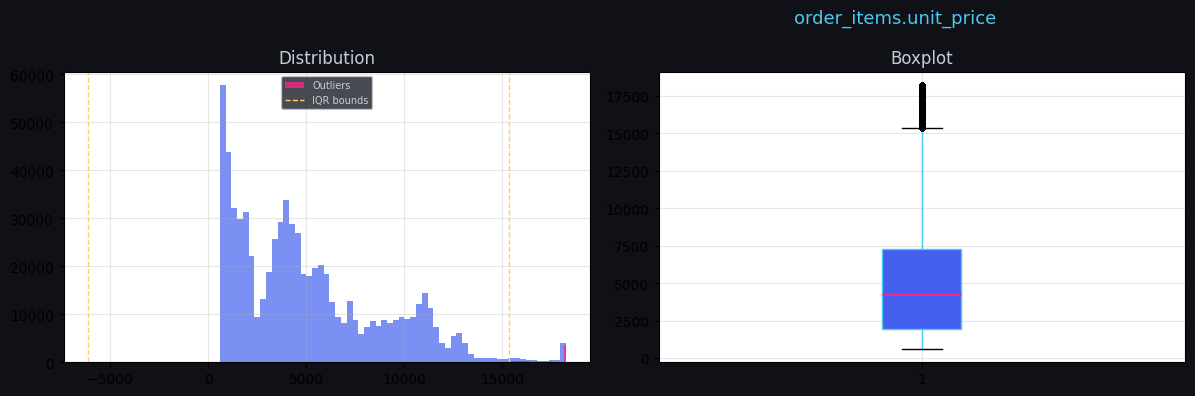


📊 Stats for order_items.unit_price


,Value
mean,5114.6902
std,3774.8179
min,392.5700
max,43056.0000
q1,1906.8900
q3,7273.7600
iqr_lower,-6143.4150
iqr_upper,15324.0650
n_iqr_outliers,8623.0000
n_zscore_outliers,5766.0000



🔴 Top outlier rows (n=8,623):


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
524764,605374,347,2,43056.00,0.0,NaN,NaN
520793,600551,347,1,42937.31,0.0,NaN,NaN
519325,598739,347,4,42268.78,0.0,NaN,NaN
524565,605128,347,6,41672.48,0.0,NaN,NaN
558645,645732,347,8,41446.30,0.0,NaN,NaN
486968,560153,347,4,41319.56,0.0,NaN,NaN
536101,619091,347,5,41103.28,0.0,NaN,NaN
489559,563097,347,6,41077.20,0.0,NaN,NaN
534871,617591,347,1,41050.55,0.0,NaN,NaN
596773,691671,347,2,40825.75,0.0,NaN,NaN


In [11]:
# ============================================================
# 🎯 Tùy chọn: Inspect một bảng + cột cụ thể
# ============================================================

TARGET_TABLE  = 'order_items'         # ← đổi tên bảng muốn xem
TARGET_COLUMN = 'unit_price'   # ← đổi tên cột muốn phân tích sâu

r   = results[TARGET_TABLE]
df  = r['df']
ov  = r['num_outliers'].get(TARGET_COLUMN)

if ov is None:
    print(f'Cột "{TARGET_COLUMN}" không phải numeric hoặc không có trong bảng {TARGET_TABLE}')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor='#0f1117')
    fig.suptitle(f'{TARGET_TABLE}.{TARGET_COLUMN}', color='#4cc9f0', fontsize=13)

    s = df[TARGET_COLUMN].dropna()
    mask = ov['outlier_mask']

    # 1. Histogram
    p1, p99 = s.quantile(0.005), s.quantile(0.995)
    axes[0].hist(s.clip(p1,p99), bins=60, color='#4361ee', alpha=0.7)
    axes[0].hist(df.loc[mask, TARGET_COLUMN].clip(p1,p99).dropna(), bins=30, color='#f72585', alpha=0.8, label='Outliers')
    axes[0].axvline(ov['iqr_lower'], color='#ffd166', ls='--', lw=1, label='IQR bounds')
    axes[0].axvline(ov['iqr_upper'], color='#ffd166', ls='--', lw=1)
    axes[0].set_title('Distribution', color='#c8ccd8')
    axes[0].legend(fontsize=7, facecolor='#1a1d27', labelcolor='#c8ccd8')
    axes[0].grid(alpha=0.3)

    # 2. Boxplot
    bp = axes[1].boxplot(s.clip(p1,p99), patch_artist=True, vert=True,
                          boxprops=dict(facecolor='#4361ee', color='#4cc9f0'),
                          whiskerprops=dict(color='#4cc9f0'),
                          medianprops=dict(color='#f72585', lw=2),
                          flierprops=dict(marker='o', color='#ffd166', alpha=0.3, ms=3))
    axes[1].set_title('Boxplot', color='#c8ccd8')
    axes[1].grid(alpha=0.3)

    # 3. Time series nếu có cột date
    dt_col = r['dt_cols'][0] if r['dt_cols'] else None
    if dt_col and dt_col in df.columns:
        tmp = df[[dt_col, TARGET_COLUMN]].dropna().sort_values(dt_col)
        axes[2].scatter(tmp[dt_col], tmp[TARGET_COLUMN].clip(p1,p99),
                        s=1, alpha=0.3, color='#4361ee')
        out_ts = tmp[mask.reindex(tmp.index, fill_value=False)]
        axes[2].scatter(out_ts[dt_col], out_ts[TARGET_COLUMN].clip(p1,p99),
                        s=12, color='#f72585', alpha=0.7, label='Outliers')
        axes[2].set_title(f'Over time ({dt_col})', color='#c8ccd8')
        axes[2].legend(fontsize=7, facecolor='#1a1d27', labelcolor='#c8ccd8')
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(f'\n📊 Stats for {TARGET_TABLE}.{TARGET_COLUMN}')
    stats_display = {k:v for k,v in ov.items() if k != 'outlier_mask'}
    display(pd.DataFrame([stats_display]).T.rename(columns={0:'Value'}))

    print(f'\n🔴 Top outlier rows (n={ov["n_total_outliers"]:,}):')
    display(df[mask].nlargest(10, TARGET_COLUMN) if ov['max'] > 0 else df[mask].head(10))

---
## Phát hiện "Duplicate Key / Conflicting Records"

*Ví dụ: Cùng key order_id nhưng các cột giá trị lại khác nhau*

#### 1. Cấu hình
- Khai báo key column(s) cho từng bảng muốn kiểm tra.
- Bỏ trống [] = tự động thử tất cả cột có thể là "ID/key"

In [12]:
CONFLICT_CONFIG = {
    'order_items': {
        'key_cols':   ['order_id'],                        # cột dùng để group
        'value_cols': ['quantity', 'unit_price'],          # cột kỳ vọng nhất quán
    },
    'orders': {
        'key_cols':   ['order_id'],
        'value_cols': ['total_amount', 'status'],
    },
    'payments': {
        'key_cols':   ['order_id'],
        'value_cols': ['amount', 'method'],
    },
    # Thêm bảng khác tại đây...
    # 'your_table': {'key_cols': ['some_id'], 'value_cols': ['col_a', 'col_b']},
}

# Nếu một bảng không có trong CONFLICT_CONFIG, tự động detect key?
AUTO_DETECT_TABLES = True    # True = thử các bảng còn lại với key tự động
AUTO_KEY_SUFFIX    = ('_id', 'id', '_key', '_code', '_no')  # hậu tố nhận diện cột key

#### 2. Engine

In [13]:
def detect_conflicting_records(df, key_cols, value_cols=None):
    """
    Tìm các nhóm có cùng key_cols nhưng value_cols khác nhau giữa các row.
    
    Returns:
        conflict_keys : DataFrame – các key bị conflict + thống kê
        conflict_rows : DataFrame – toàn bộ row thuộc các nhóm conflict
    """
    missing = [c for c in key_cols if c not in df.columns]
    if missing:
        return None, None, f"Key cols không tồn tại: {missing}"

    # Nếu không chỉ định value_cols → dùng tất cả cột còn lại (trừ key)
    if not value_cols:
        value_cols = [c for c in df.columns if c not in key_cols]
    value_cols = [c for c in value_cols if c in df.columns]

    # Với mỗi key, đếm số giá trị distinct của từng value_col
    agg = {col: 'nunique' for col in value_cols}
    grouped = df.groupby(key_cols).agg({'**count**': 'size', **agg}) if False else (
        df.groupby(key_cols)
          .agg(row_count=('_dummy_', 'size') if '_dummy_' in df else
               (key_cols[0], 'count'),
               **{f'{c}_nuniq': (c, 'nunique') for c in value_cols})
          .reset_index()
    )

    # Key bị conflict = nhóm có ít nhất 1 value_col có nunique > 1
    nuniq_cols = [f'{c}_nuniq' for c in value_cols]
    conflict_mask = grouped[nuniq_cols].gt(1).any(axis=1)
    conflict_keys = grouped[conflict_mask].copy()
    conflict_keys['n_conflicting_cols'] = grouped[nuniq_cols][conflict_mask].gt(1).sum(axis=1)

    if len(conflict_keys) == 0:
        return conflict_keys, pd.DataFrame(), None

    # Lấy toàn bộ row thuộc các nhóm conflict để xem chi tiết
    conflict_rows = df.merge(
        conflict_keys[key_cols],
        on=key_cols,
        how='inner'
    ).sort_values(key_cols)

    return conflict_keys, conflict_rows, None


def auto_detect_key_cols(df, suffixes):
    """Tự nhận diện cột key dựa trên tên cột."""
    return [c for c in df.columns
            if any(c.lower().endswith(s) or c.lower() == s.strip('_') for s in suffixes)]



#### 3. Chạy phân tích

  🔁 CONFLICTING RECORDS DETECTION

🔴 [order_items]  key=['order_id']
   → 66,457 key(s) bị conflict  (10.27%)  |  134,181 rows liên quan


**Top conflict keys – `order_items`**

,order_id,row_count,quantity_nuniq,unit_price_nuniq,n_conflicting_cols
646933,834347,2,2,2,2
6,8,2,2,2,2
14,20,2,2,2,2
38,47,2,2,2,2
39,48,2,2,2,2
56,72,2,2,2,2
80,100,2,2,2,2
95,125,2,2,2,2
646747,834032,2,2,2,2
646733,834016,2,2,2,2


**Sample conflict rows (first key group) – `order_items`**

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
6,8,1934,6,1602.920000,0.000000,nan,nan
7,8,1935,4,1642.510000,0.000000,nan,nan


NameError: name 'PALETTE' is not defined

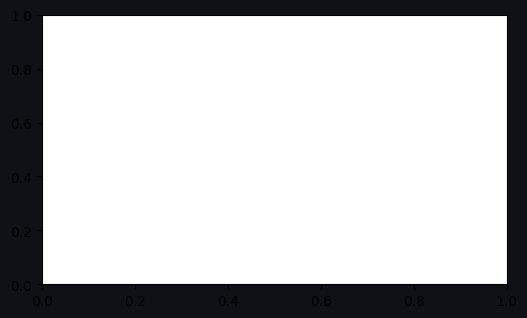

In [14]:
all_conflict_summary = []

# Bảng được cấu hình thủ công
tables_to_check = dict(CONFLICT_CONFIG)

# Bổ sung auto-detect cho bảng chưa có trong config
if AUTO_DETECT_TABLES:
    for tbl in tables_name:
        if tbl not in tables_to_check:
            df_tmp = results[tbl]['df']
            auto_keys = auto_detect_key_cols(df_tmp, AUTO_KEY_SUFFIX)
            if auto_keys:
                tables_to_check[tbl] = {'key_cols': auto_keys[:2], 'value_cols': []}

print('=' * 65)
print('  🔁 CONFLICTING RECORDS DETECTION')
print('=' * 65)

for tbl, cfg_t in tables_to_check.items():
    if tbl not in results:
        print(f'\n⚠️  Bỏ qua [{tbl}] – không có trong results')
        continue

    df         = results[tbl]['df']
    key_cols   = cfg_t['key_cols']
    value_cols = cfg_t.get('value_cols', [])

    conflict_keys, conflict_rows, err = detect_conflicting_records(df, key_cols, value_cols)

    if err:
        print(f'\n⚠️  [{tbl}] {err}')
        continue

    n_conflict_keys = len(conflict_keys)
    n_conflict_rows = len(conflict_rows) if conflict_rows is not None else 0
    pct = round(n_conflict_keys / df[key_cols].drop_duplicates().__len__() * 100, 2)

    status = '🔴' if n_conflict_keys > 0 else '✅'
    print(f'\n{status} [{tbl}]  key={key_cols}')
    print(f'   → {n_conflict_keys:,} key(s) bị conflict  ({pct}%)'
          f'  |  {n_conflict_rows:,} rows liên quan')

    all_conflict_summary.append({
        'Table'          : tbl,
        'Key cols'       : str(key_cols),
        'Value cols checked': str(value_cols or 'all'),
        'Conflict keys'  : n_conflict_keys,
        'Conflict rows'  : n_conflict_rows,
        'Conflict key %' : pct,
    })

    if n_conflict_keys == 0:
        continue

    # ── Hiển thị chi tiết ──
    display(Markdown(f'**Top conflict keys – `{tbl}`**'))
    display(conflict_keys.sort_values('n_conflicting_cols', ascending=False).head(10)
            .style.background_gradient(subset=['n_conflicting_cols'], cmap='Reds')
            .set_table_styles([{'selector':'th','props':'background:#1a1d27;color:#f72585'}]))

    display(Markdown(f'**Sample conflict rows (first key group) – `{tbl}`**'))
    first_key_val = conflict_keys.iloc[0][key_cols].to_dict()
    sample_group  = df.loc[(df[key_cols] == pd.Series(first_key_val)).all(axis=1)]
    display(sample_group.style
            .highlight_null(color='#ff000040')
            .set_table_styles([{'selector':'th','props':'background:#1a1d27;color:#4cc9f0'}]))

    # ── Visualize: heatmap số conflict per value_col ──
    nuniq_cols = [c for c in conflict_keys.columns if c.endswith('_nuniq')]
    if nuniq_cols:
        fig, ax = plt.subplots(figsize=(max(6, len(nuniq_cols)*1.5), 3.5), facecolor='#0f1117')
        heat = conflict_keys[nuniq_cols].gt(1).sum().rename(
            index=lambda x: x.replace('_nuniq',''))
        ax.bar(heat.index, heat.values, color=PALETTE[:len(heat)], edgecolor='none', alpha=0.85)
        ax.set_title(f'[{tbl}] Số key bị conflict theo từng value column',
                     color='#c8ccd8', fontsize=10)
        ax.set_xticklabels(heat.index, rotation=25, ha='right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        for i, v in enumerate(heat.values):
            if v > 0:
                ax.text(i, v + 0.2, str(v), ha='center', fontsize=8, color='#ffd166')
        plt.tight_layout()
        plt.show()

#### 4. Tổng hợp

In [ ]:
if all_conflict_summary:
    print('\n' + '=' * 65)
    print('  📋 CONFLICT SUMMARY (tất cả bảng)')
    print('=' * 65)
    summary_conflict = pd.DataFrame(all_conflict_summary)
    display(summary_conflict.style
            .background_gradient(subset=['Conflict keys','Conflict key %'], cmap='RdYlGn_r')
            .format({'Conflict key %': '{:.2f}%'})
            .set_table_styles([{'selector':'th','props':'background:#1a1d27;color:#4cc9f0;padding:6px'}]))


  📋 CONFLICT SUMMARY (tất cả bảng)


,Table,Key cols,Value cols checked,Conflict keys,Conflict rows,Conflict key %
0,order_items,['order_id'],"['quantity', 'unit_price']",66457,134181,10.27%
1,orders,['order_id'],"['total_amount', 'status']",0,0,0.00%
2,payments,['order_id'],"['amount', 'method']",0,0,0.00%
3,customers,['customer_id'],all,0,0,0.00%
4,inventory,['product_id'],all,1514,60137,93.23%
5,products,['product_id'],all,0,0,0.00%
6,promotions,['promo_id'],all,0,0,0.00%
7,returns,"['return_id', 'order_id']",all,0,0,0.00%
8,reviews,"['review_id', 'order_id']",all,0,0,0.00%
9,shipments,['order_id'],all,0,0,0.00%
